# 对比实验：8个模型 × 3个外部数据集训练与评估
## 数据集：LoveDA / Potsdam / Vaihingen
本 Notebook 将：
1. 下载并预处理三个遥感数据集（植被二分类）
2. 用每个数据集分别**训练**并**评估** 8 个模型：
   - SAM2-Tiny、SAM2.1-Tiny、MobileSAM、MobileSAMV2（1024×1024 输入）
   - UNet（ResNet34）、DeepLabV3+（ResNet50）（512×512 输入）
   - YOLO11s-seg（512×512 输入）
   - SegEarth-OV（零样本推理，无需训练）
3. 汇总 IoU / F1 / Accuracy 对比表格并保存结果

In [ ]:
# ============================================================
# Cell 0: 挂载 Drive + 安装全部依赖
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import subprocess, sys

def pip(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

pip('hydra-core')
pip('iopath')
pip('segmentation-models-pytorch')
pip('albumentations')
pip('ultralytics')
pip('open_clip_torch')
pip('ftfy')
pip('regex')
pip('kaggle')

# SAM2 + MobileSAM（从 Drive 本地安装，与原始 notebooks 保持一致）
import os, sys
DRIVE = '/content/drive/MyDrive/vegetation_models_v2'

# SAM2 代码
sam2_code = f'{DRIVE}/1_SAM2_Tiny/code'
if os.path.exists(sam2_code):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-e', sam2_code])
    sys.path.insert(0, sam2_code)

# MobileSAM（公开 pip 包）
pip('git+https://github.com/ChaoningZhang/MobileSAM.git')

import torch
import numpy as np
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ 环境准备完成，设备: {DEVICE}')


Mounted at /content/drive
✅ 环境准备完成，设备: cuda


## Step 1 — 下载 & 预处理数据集

In [ ]:
# ============================================================
# Cell 1: 下载 LoveDA
# ============================================================
import os
from PIL import Image
import numpy as np

os.makedirs('/content/loveda', exist_ok=True)

print('📥 下载 LoveDA Train...')
!wget -q --show-progress \
    "https://zenodo.org/records/5706578/files/Train.zip?download=1" \
    -O /content/loveda/Train.zip

print('📥 下载 LoveDA Val...')
!wget -q --show-progress \
    "https://zenodo.org/records/5706578/files/Val.zip?download=1" \
    -O /content/loveda/Val.zip

print('📦 解压中...')
!unzip -q /content/loveda/Train.zip -d /content/loveda/
!unzip -q /content/loveda/Val.zip   -d /content/loveda/
!rm  /content/loveda/Train.zip /content/loveda/Val.zip
print('✅ LoveDA 下载完成')
!find /content/loveda -maxdepth 4 -type d


📥 下载 LoveDA Train...
/content/loveda/Tra 100%[===================>]   3.75G  8.01MB/s    in 8m 40s  
📥 下载 LoveDA Val...
/content/loveda/Val 100%[===================>]   2.26G  10.6MB/s    in 6m 37s  
📦 解压中...
replace /content/loveda/Train/Rural/images_png/0.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: replace /content/loveda/Val/Rural/images_png/2522.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: ✅ LoveDA 下载完成
/content/loveda
/content/loveda/Train
/content/loveda/Train/Rural
/content/loveda/Train/Rural/masks_png
/content/loveda/Train/Rural/images_png
/content/loveda/Train/Urban
/content/loveda/Train/Urban/masks_png
/content/loveda/Train/Urban/images_png
/content/loveda/Val
/content/loveda/Val/Rural
/content/loveda/Val/Rural/masks_png
/content/loveda/Val/Rural/images_png
/content/loveda/Val/Urban
/content/loveda/Val/Urban/masks_png
/content/loveda/Val/Urban/images_png


In [ ]:
# ============================================================
# Cell 2: 下载 Potsdam + Vaihingen（Kaggle）
# ============================================================
import os

os.makedirs('/content/isprs', exist_ok=True)
os.environ['KAGGLE_CONFIG_DIR'] = '/content'

# ⚠️ 请先将 kaggle.json 上传到 /content/
#    或在下方手动填入 KAGGLE_USERNAME / KAGGLE_KEY
# import json
# with open('/content/kaggle.json', 'w') as f:
#     json.dump({'username': 'YOUR_USERNAME', 'key': 'YOUR_KEY'}, f)

print('📥 下载 Potsdam + Vaihingen...')
!kaggle datasets download -d bkfateam/potsdamvaihingen \
    -p /content/isprs --unzip
print('✅ ISPRS 下载完成')
!find /content/isprs -maxdepth 3 -type d


📥 下载 Potsdam + Vaihingen...
Dataset URL: https://www.kaggle.com/datasets/bkfateam/potsdamvaihingen
License(s): DbCL-1.0
Resuming from 91226112 bytes (14808149412 bytes left)...
100% 13.9G/13.9G [15:33<00:00, 15.9MB/s]

✅ ISPRS 下载完成
/content/isprs
/content/isprs/ISPRS_semantic_labeling_Vaihingen
/content/isprs/ISPRS_semantic_labeling_Vaihingen/gts_for_participants
/content/isprs/ISPRS_semantic_labeling_Vaihingen/dsm
/content/isprs/ISPRS_semantic_labeling_Vaihingen/top
/content/isprs/3_ortho_irrg
/content/isprs/3_ortho_irrg/3_Ortho_IRRG
/content/isprs/1_DSM
/content/isprs/1_DSM/1_DSM
/content/isprs/isprs_semantic_labeling_vaihingen
/content/isprs/isprs_semantic_labeling_vaihingen/gts_for_participants
/content/isprs/isprs_semantic_labeling_vaihingen/dsm
/content/isprs/isprs_semantic_labeling_vaihingen/top
/content/isprs/5_Labels_for_participants_no_Boundary
/content/isprs/5_Labels_for_participants_no_Boundary/5_Labels_for_participants_no_Boundary
/content/isprs/5_Labels_for_participants
/

In [10]:
# ============================================================
# Cell 3: 预处理 LoveDA → 植被二分类 patch（≤500张）
# ============================================================
import os, numpy as np
from PIL import Image

os.makedirs('/content/binary/loveda/JPEGImages',        exist_ok=True)
os.makedirs('/content/binary/loveda/SegmentationClass', exist_ok=True)

OUT_IMG  = '/content/binary/loveda/JPEGImages'
OUT_MASK = '/content/binary/loveda/SegmentationClass'

SPLITS  = ['Train', 'Val']
SCENES  = ['Urban', 'Rural']
total   = 0
MAX_NUM = 500

for split in SPLITS:
    for scene in SCENES:
        if total >= MAX_NUM: break
        for img_dir_candidate in [
            f'/content/loveda/{split}/{scene}/images_png',
            f'/content/loveda/{split}/{scene}/images',
        ]:
            if os.path.exists(img_dir_candidate):
                img_dir = img_dir_candidate; break
        else:
            print(f'⚠️  找不到图像目录: {split}/{scene}，跳过'); continue

        mask_dir = img_dir.replace('images_png', 'masks_png').replace('/images', '/masks_png')
        if not os.path.exists(mask_dir):
            print(f'⚠️  找不到mask目录，跳过'); continue

        img_files = sorted([f for f in os.listdir(img_dir)
                            if f.lower().endswith(('.png','.jpg','.tif'))])
        print(f'{split}/{scene}: {len(img_files)} 张')

        for fname in img_files:
            if total >= MAX_NUM: break
            stem      = os.path.splitext(fname)[0]
            mask_path = os.path.join(mask_dir, stem + '.png')
            if not os.path.exists(mask_path): continue
            try:
                img_arr  = np.array(Image.open(os.path.join(img_dir, fname)).convert('RGB'))
                mask_arr = np.array(Image.open(mask_path))
                bm = np.zeros(mask_arr.shape[:2], dtype=np.uint8)
                bm[(mask_arr == 6) | (mask_arr == 7)] = 255      # Forest / Agriculture
                out_stem = f'loveda_{total:04d}'
                Image.fromarray(img_arr).save(f'{OUT_IMG}/{out_stem}.png')
                Image.fromarray(bm).save(f'{OUT_MASK}/{out_stem}.png')
                total += 1
            except Exception as e:
                print(f'  处理失败 {fname}: {e}')

print(f'\n✅ LoveDA 预处理完成: {total} 张')


Train/Urban: 1156 张

✅ LoveDA 预处理完成: 500 张


In [11]:
# ============================================================
# Cell 4: 预处理 Potsdam → 植被二分类 patch（≤400张）
# ============================================================
import os, numpy as np
from PIL import Image

IMG_ROOT  = '/content/isprs/3_Ortho_IRRG/3_Ortho_IRRG'
MASK_ROOT = '/content/isprs/5_Labels_for_participants_no_Boundary/5_Labels_for_participants_no_Boundary'

os.makedirs('/content/binary/potsdam/JPEGImages',        exist_ok=True)
os.makedirs('/content/binary/potsdam/SegmentationClass', exist_ok=True)

OUT_IMG  = '/content/binary/potsdam/JPEGImages'
OUT_MASK = '/content/binary/potsdam/SegmentationClass'

def save_patches(img_arr, bin_mask, out_img, out_mask,
                 prefix, start=0, patch=512, min_veg=0.05):
    H, W = img_arr.shape[:2]
    saved = 0
    for y in range(0, H - patch + 1, patch):
        for x in range(0, W - patch + 1, patch):
            ip = img_arr[y:y+patch, x:x+patch]
            mp = bin_mask[y:y+patch, x:x+patch]
            if (mp==255).sum() / patch**2 < min_veg: continue
            stem = f'{prefix}_{start+saved:04d}'
            Image.fromarray(ip).save(f'{out_img}/{stem}.png')
            Image.fromarray(mp).save(f'{out_mask}/{stem}.png')
            saved += 1
    return saved

img_files  = sorted([f for f in os.listdir(IMG_ROOT)  if f.endswith('.tif')])
mask_files = sorted([f for f in os.listdir(MASK_ROOT) if f.endswith('.tif')])
mask_dict  = {mf.replace('_label_noBoundary.tif', ''): mf for mf in mask_files}

total_p = 0
MAX_P   = 400

for img_fname in img_files:
    if total_p >= MAX_P: break
    key = img_fname.replace('_IRRG.tif', '')
    if key not in mask_dict: continue
    try:
        img_arr  = np.array(Image.open(f'{IMG_ROOT}/{img_fname}'))[:,:,:3]
        mask_arr = np.array(Image.open(f'{MASK_ROOT}/{mask_dict[key]}').convert('RGB'))
        bm = np.zeros(mask_arr.shape[:2], dtype=np.uint8)
        bm[np.all(mask_arr==[0,255,0],   axis=2)] = 255
        bm[np.all(mask_arr==[0,255,255], axis=2)] = 255
        n = save_patches(img_arr.astype(np.uint8), bm, OUT_IMG, OUT_MASK,
                         'potsdam', total_p)
        total_p += n
    except Exception as e:
        print(f'读取失败: {e}')

print(f'✅ Potsdam 预处理完成: {total_p} 张 patch')


✅ Potsdam 预处理完成: 454 张 patch


In [12]:
# ============================================================
# Cell 5: 预处理 Vaihingen → 植被二分类 patch（≤400张）
# ============================================================
import os, numpy as np
from PIL import Image

IMG_ROOT  = '/content/isprs/isprs_semantic_labeling_vaihingen/top'
MASK_ROOT = '/content/isprs/isprs_semantic_labeling_vaihingen/gts_for_participants'

os.makedirs('/content/binary/vaihingen/JPEGImages',        exist_ok=True)
os.makedirs('/content/binary/vaihingen/SegmentationClass', exist_ok=True)

OUT_IMG  = '/content/binary/vaihingen/JPEGImages'
OUT_MASK = '/content/binary/vaihingen/SegmentationClass'

mask_files = set(os.listdir(MASK_ROOT))
img_files  = sorted([f for f in os.listdir(IMG_ROOT) if f.endswith('.tif')])

total_v = 0
MAX_V   = 400

for img_fname in img_files:
    if total_v >= MAX_V: break
    if img_fname not in mask_files: continue
    try:
        img_arr  = np.array(Image.open(f'{IMG_ROOT}/{img_fname}'))[:,:,:3]
        mask_arr = np.array(Image.open(f'{MASK_ROOT}/{img_fname}').convert('RGB'))
        bm = np.zeros(mask_arr.shape[:2], dtype=np.uint8)
        bm[np.all(mask_arr==[0,255,0],   axis=2)] = 255
        bm[np.all(mask_arr==[0,255,255], axis=2)] = 255
        H, W = img_arr.shape[:2]
        for y in range(0, H - 512 + 1, 512):
            for x in range(0, W - 512 + 1, 512):
                if total_v >= MAX_V: break
                ip = img_arr[y:y+512, x:x+512]
                mp = bm[y:y+512, x:x+512]
                if (mp==255).sum() / 512**2 < 0.05: continue
                stem = f'vaihingen_{total_v:04d}'
                Image.fromarray(ip.astype(np.uint8)).save(f'{OUT_IMG}/{stem}.png')
                Image.fromarray(mp).save(f'{OUT_MASK}/{stem}.png')
                total_v += 1
    except Exception as e:
        print(f'读取失败 {img_fname}: {e}')

print(f'✅ Vaihingen 预处理完成: {total_v} 张 patch')

print('\n📊 三数据集汇总检查:')
for name, path in [('LoveDA',    '/content/binary/loveda/JPEGImages'),
                   ('Potsdam',   '/content/binary/potsdam/JPEGImages'),
                   ('Vaihingen', '/content/binary/vaihingen/JPEGImages')]:
    n = len(os.listdir(path)) if os.path.exists(path) else 0
    print(f'  {"✅" if n > 0 else "❌"} {name}: {n} 张')


✅ Vaihingen 预处理完成: 201 张 patch

📊 三数据集汇总检查:
  ✅ LoveDA: 500 张
  ✅ Potsdam: 454 张
  ✅ Vaihingen: 201 张


## Step 2 — 通用工具：数据集类 / 损失 / 评估

In [13]:
# ============================================================
# Cell 6: 通用 Dataset、损失函数、评估函数
# ============================================================
import os, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DRIVE  = '/content/drive/MyDrive/vegetation_models_v2'

# ── 1. Dataset（支持 512 / 1024） ──────────────────────────
class BinaryDataset(Dataset):
    """通用二分类遥感数据集（支持任意输入尺寸）"""
    def __init__(self, img_dir, mask_dir, img_size=512, augment=False, max_samples=None):
        self.img_dir  = img_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        files = sorted(os.listdir(img_dir))
        if max_samples:
            files = files[:max_samples]
        self.files = [f for f in files
                      if f.lower().endswith(('.png','.jpg','.jpeg'))]

        # 验证 mask 是否存在
        valid = []
        for f in self.files:
            stem = os.path.splitext(f)[0]
            if os.path.exists(os.path.join(mask_dir, stem + '.png')):
                valid.append(f)
        self.files = valid
        print(f'    成功配对: {len(self.files)} 张  (size={img_size})')

        self.tf = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])

    def __len__(self): return len(self.files)

    def __getitem__(self, i):
        fname = self.files[i]
        stem  = os.path.splitext(fname)[0]
        img   = self.tf(Image.open(os.path.join(self.img_dir, fname)).convert('RGB'))
        mask  = np.array(Image.open(
                    os.path.join(self.mask_dir, stem + '.png')
                ).resize((self.img_size, self.img_size), Image.NEAREST))
        mask  = torch.from_numpy((mask > 0).astype(np.int64))
        return img, mask, fname


# ── 2. 损失函数 ────────────────────────────────────────────
def dice_loss(pred, target, smooth=1.0):
    pred   = torch.softmax(pred, dim=1)[:, 1]
    target = target.float()
    inter  = (pred * target).sum(dim=(1,2))
    union  = pred.sum(dim=(1,2)) + target.sum(dim=(1,2))
    return 1 - ((2*inter + smooth) / (union + smooth)).mean()

def focal_loss(pred, target, gamma=2.0, alpha=0.75):
    ce = F.cross_entropy(pred, target, reduction='none')
    pt = torch.exp(-ce)
    w  = target.float() * alpha + (1 - target.float()) * (1 - alpha)
    return (w * (1 - pt)**gamma * ce).mean()

def combined_loss(pred, target):
    return 0.4 * focal_loss(pred, target) + 0.6 * dice_loss(pred, target)


# ── 3. 评估函数 ────────────────────────────────────────────
def evaluate(model, loader, device=DEVICE):
    model.eval()
    iou_list, f1_list, acc_list = [], [], []
    with torch.no_grad():
        for imgs, masks, _ in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs).argmax(dim=1)
            for i in range(preds.size(0)):
                p, m = preds[i], masks[i]
                tp = ((p==1)&(m==1)).sum().item()
                fp = ((p==1)&(m==0)).sum().item()
                fn = ((p==0)&(m==1)).sum().item()
                tn = ((p==0)&(m==0)).sum().item()
                iou_list.append(tp/(tp+fp+fn+1e-6))
                f1_list.append(2*tp/(2*tp+fp+fn+1e-6))
                acc_list.append((tp+tn)/(tp+fp+fn+tn+1e-6))
    return float(np.mean(iou_list)), float(np.mean(f1_list)), float(np.mean(acc_list))


# ── 4. 通用训练函数 ────────────────────────────────────────
def train_model(model, train_loader, val_loader, num_epochs,
                save_path, optimizer, scheduler, model_name='Model'):
    scaler  = GradScaler('cuda')
    best_iou = 0
    train_log = []

    print('='*65)
    print(f'🚀 {model_name}  |  {num_epochs}轮  |  设备: {DEVICE}')
    print(f'   可训练参数: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
    print('='*65)

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_loss = 0
        for imgs, masks, _ in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            with autocast('cuda'):
                loss = combined_loss(model(imgs), masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()

        scheduler.step()
        avg_loss = total_loss / len(train_loader)
        iou, f1, acc = evaluate(model, val_loader)
        train_log.append({'epoch': epoch, 'loss': avg_loss,
                          'iou': iou, 'f1': f1, 'acc': acc})

        if epoch % 10 == 0 or iou > best_iou:
            print(f'Epoch [{epoch:03d}/{num_epochs}] '
                  f'Loss:{avg_loss:.4f} IoU:{iou:.4f} F1:{f1:.4f} Acc:{acc:.4f}')

        if iou > best_iou:
            best_iou = iou
            torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                        'best_iou': best_iou}, save_path)
            print(f'  💾 最优模型已保存 (IoU={best_iou:.4f})')

    return best_iou, train_log


print('✅ 通用工具函数定义完成')


✅ 通用工具函数定义完成


In [14]:
# ============================================================
# Cell 7: 为三个数据集构建 DataLoader（80/20 划分训练/验证）
# ============================================================
from torch.utils.data import random_split

DATASETS = {
    'LoveDA':    ('/content/binary/loveda/JPEGImages',
                  '/content/binary/loveda/SegmentationClass'),
    'Potsdam':   ('/content/binary/potsdam/JPEGImages',
                  '/content/binary/potsdam/SegmentationClass'),
    'Vaihingen': ('/content/binary/vaihingen/JPEGImages',
                  '/content/binary/vaihingen/SegmentationClass'),
}

# 每个数据集各建两套 DataLoader：512 和 1024 输入
loaders_512  = {}   # UNet / DeepLabV3+ / YOLO
loaders_1024 = {}   # SAM 系列

print('📦 构建 DataLoader:')
for ds_name, (img_d, mask_d) in DATASETS.items():
    print(f'  {ds_name}:')
    for img_size, store in [(512, loaders_512), (1024, loaders_1024)]:
        ds_full = BinaryDataset(img_d, mask_d, img_size=img_size)
        n_train = int(0.8 * len(ds_full))
        n_val   = len(ds_full) - n_train
        ds_train, ds_val = random_split(
            ds_full, [n_train, n_val],
            generator=torch.Generator().manual_seed(42))
        train_ld = DataLoader(ds_train, batch_size=4, shuffle=True,
                              num_workers=2, pin_memory=True)
        val_ld   = DataLoader(ds_val,   batch_size=4, shuffle=False,
                              num_workers=2, pin_memory=True)
        store[ds_name] = {'train': train_ld, 'val': val_ld,
                          'n_train': n_train, 'n_val': n_val}

print('\n✅ DataLoader 准备完成')
for name in DATASETS:
    print(f'  {name}: train={loaders_512[name]["n_train"]} / val={loaders_512[name]["n_val"]}')


📦 构建 DataLoader:
  LoveDA:
    成功配对: 500 张  (size=512)
    成功配对: 500 张  (size=1024)
  Potsdam:
    成功配对: 454 张  (size=512)
    成功配对: 454 张  (size=1024)
  Vaihingen:
    成功配对: 201 张  (size=512)
    成功配对: 201 张  (size=1024)

✅ DataLoader 准备完成
  LoveDA: train=400 / val=100
  Potsdam: train=363 / val=91
  Vaihingen: train=160 / val=41


## Step 3 — 模型定义

In [24]:
# ============================================================
# Cell 8: 定义全部 7 个分割模型（SegEarth-OV 单独处理）
# ============================================================
import torch, torch.nn as nn
import segmentation_models_pytorch as smp

# ── (a) SAM2-Tiny ─────────────────────────────────────────
class SAM2Seg(nn.Module):
    def __init__(self, cfg, ckpt_path, num_classes=2):
        super().__init__()
        from sam2.build_sam import build_sam2
        sam2 = build_sam2(cfg, ckpt_path, device=DEVICE)
        self.encoder  = sam2.image_encoder
        self.seg_head = self._make_head(256, num_classes, 1024)

    @staticmethod
    def _make_head(in_ch, num_cls, out_size):
        return nn.Sequential(
            nn.Conv2d(in_ch, 256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Conv2d(256,   128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128,    64,3,padding=1), nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.Conv2d(64, num_cls, 1),
            nn.Upsample(size=(out_size, out_size), mode='bilinear', align_corners=False)
        )

    def forward(self, x):
        feat = self.encoder(x)
        if isinstance(feat, dict): feat = feat['backbone_fpn'][-1]
        return self.seg_head(feat)


# ── (b) SAM2.1-Tiny ──────────────────────────────────────
class SAM21Seg(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        from sam2.build_sam import build_sam2_hf
        sam21 = build_sam2_hf('facebook/sam2.1-hiera-tiny', device=DEVICE, mode='train')
        self.encoder  = sam21.image_encoder
        self.seg_head = SAM2Seg._make_head(256, num_classes, 1024)

    def forward(self, x):
        feat = self.encoder(x)
        if isinstance(feat, dict): feat = feat['backbone_fpn'][-1]
        return self.seg_head(feat)


# ── (c) MobileSAM ────────────────────────────────────────
class MobileSAMSeg(nn.Module):
    def __init__(self, ckpt_path, num_classes=2):
        super().__init__()
        from mobile_sam import sam_model_registry
        sam = sam_model_registry['vit_t'](checkpoint=ckpt_path)
        self.encoder  = sam.image_encoder
        self.seg_head = SAM2Seg._make_head(256, num_classes, 1024)

    def forward(self, x):
        return self.seg_head(self.encoder(x))


# ── (d) MobileSAMV2（与 MobileSAM 共享 encoder 结构） ────
class MobileSAMV2Seg(nn.Module):
    def __init__(self, ckpt_path, num_classes=2):
        super().__init__()
        from mobile_sam import sam_model_registry
        sam = sam_model_registry['vit_t'](checkpoint=ckpt_path)
        self.encoder  = sam.image_encoder
        self.seg_head = SAM2Seg._make_head(256, num_classes, 1024)
        # 解冻全部参数
        for p in self.parameters(): p.requires_grad = True

    def forward(self, x):
        return self.seg_head(self.encoder(x))


# ── (e) UNet（ResNet34） ──────────────────────────────────
def build_unet():
    return smp.Unet(encoder_name='resnet34', encoder_weights='imagenet',
                    in_channels=3, classes=2, activation=None)


# ── (f) DeepLabV3+（ResNet50） ────────────────────────────
def build_deeplabv3():
    return smp.DeepLabV3Plus(encoder_name='resnet50', encoder_weights='imagenet',
                              in_channels=3, classes=2, activation=None,
                              encoder_output_stride=16)


print('✅ 模型类定义完成')


✅ 模型类定义完成


## Step 4 — 训练 & 评估（每个数据集 × 7个模型）

In [ ]:
# ============================================================
# Cell 9: 主训练循环（三数据集 × 7个分割模型）
#         - SAM系列 / UNet / DeepLabV3+ 全量微调 100轮
#         - 结果保存到 Drive
# ============================================================
import os, json, traceback
import torch, torch.optim as optim
import numpy as np

DRIVE      = '/content/drive/MyDrive/vegetation_models_v2'
NUM_EPOCHS = 100

# ── 权重路径（与原始 notebooks 保持一致） ─────────────────
SAM2_CFG     = 'sam2_hiera_t.yaml'
SAM2_CKPT    = f'{DRIVE}/1_SAM2_Tiny/weights/sam2_hiera_tiny.pt'
MOBILE_CKPT  = f'{DRIVE}/2_MobileSAM/weights/mobile_sam.pt'

# ── 汇总结果容器 ──────────────────────────────────────────
ALL_RESULTS = {}   # {ds_name: {model_name: {iou, f1, acc}}}

# ── 对每个数据集循环 ──────────────────────────────────────
for ds_name in ['LoveDA', 'Potsdam', 'Vaihingen']:
    print('\n' + '='*70)
    print(f'🌍 数据集: {ds_name}')
    print('='*70)

    ds_result = {}
    DS_SAVE   = f'{DRIVE}/cross_dataset/{ds_name}'
    os.makedirs(DS_SAVE, exist_ok=True)

    ld512  = loaders_512[ds_name]
    ld1024 = loaders_1024[ds_name]

    # ====================================================
    # 模型配置表：(模型名, 构建函数, 使用的loader键, 存储文件名)
    # ====================================================
    def model_configs():
        configs = []

        # SAM2-Tiny
        if os.path.exists(SAM2_CKPT):
            configs.append(('SAM2-Tiny',
                lambda: SAM2Seg(SAM2_CFG, SAM2_CKPT, 2).to(DEVICE),
                ld1024, 'sam2tiny.pth'))
        else:
            print(f'  ⚠️  SAM2 权重不存在，跳过: {SAM2_CKPT}')

        # SAM2.1-Tiny
        configs.append(('SAM2.1-Tiny',
            lambda: SAM21Seg(2).to(DEVICE),
            ld1024, 'sam21tiny.pth'))

        # MobileSAM
        if os.path.exists(MOBILE_CKPT):
            configs.append(('MobileSAM',
                lambda: MobileSAMSeg(MOBILE_CKPT, 2).to(DEVICE),
                ld1024, 'mobilesam.pth'))
        else:
            print(f'  ⚠️  MobileSAM 权重不存在，跳过: {MOBILE_CKPT}')

        # MobileSAMV2
        if os.path.exists(MOBILE_CKPT):
            configs.append(('MobileSAMV2',
                lambda: MobileSAMV2Seg(MOBILE_CKPT, 2).to(DEVICE),
                ld1024, 'mobilesamv2.pth'))

        # UNet
        configs.append(('UNet',
            lambda: build_unet().to(DEVICE),
            ld512, 'unet.pth'))

        # DeepLabV3+
        configs.append(('DeepLabV3+',
            lambda: build_deeplabv3().to(DEVICE),
            ld512, 'deeplabv3plus.pth'))

        return configs

    for model_name, build_fn, loaders, fname in model_configs():
        save_path = os.path.join(DS_SAVE, fname)
        log_path  = save_path.replace('.pth', '_log.json')

        print(f'\n  ▶ 训练 {model_name}  [{ds_name}]  ...')
        try:
            model = build_fn()

            # 差异化学习率
            if hasattr(model, 'encoder') and hasattr(model, 'seg_head'):
                optimizer = optim.AdamW([
                    {'params': model.encoder.parameters(),  'lr': 5e-5},
                    {'params': model.seg_head.parameters(), 'lr': 5e-4},
                ], weight_decay=1e-4)
            elif hasattr(model, 'encoder') and hasattr(model, 'decoder'):
                optimizer = optim.AdamW([
                    {'params': model.encoder.parameters(),            'lr': 5e-5},
                    {'params': model.decoder.parameters(),            'lr': 5e-4},
                    {'params': model.segmentation_head.parameters(),  'lr': 5e-4},
                ], weight_decay=1e-4)
            else:
                optimizer = optim.AdamW(model.parameters(), lr=1e-4,
                                        weight_decay=1e-4)

            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

            best_iou, train_log = train_model(
                model,
                loaders['train'], loaders['val'],
                NUM_EPOCHS, save_path, optimizer, scheduler,
                model_name=f'{model_name} @ {ds_name}'
            )

            # 最终评估
            ckpt = torch.load(save_path, map_location=DEVICE, weights_only=False)
            model.load_state_dict(ckpt['model_state'])
            iou, f1, acc = evaluate(model, loaders['val'])
            ds_result[model_name] = {'iou': round(iou,4),
                                     'f1':  round(f1,4),
                                     'acc': round(acc,4)}
            print(f'  ✅ {model_name}: IoU={iou:.4f}  F1={f1:.4f}  Acc={acc:.4f}')

            with open(log_path, 'w') as f:
                json.dump(train_log, f, indent=2)

            del model
            torch.cuda.empty_cache()

        except Exception as e:
            print(f'  ❌ {model_name} 失败: {e}')
            traceback.print_exc()
            ds_result[model_name] = {'iou': None, 'f1': None, 'acc': None}

    ALL_RESULTS[ds_name] = ds_result

# ── 保存汇总结果 ───────────────────────────────────────────
result_path = f'{DRIVE}/cross_dataset/cross_dataset_results.json'
os.makedirs(os.path.dirname(result_path), exist_ok=True)
with open(result_path, 'w', encoding='utf-8') as f:
    json.dump(ALL_RESULTS, f, indent=2, ensure_ascii=False)

print('\n✅ 所有模型训练完成，结果已保存:', result_path)



🌍 数据集: LoveDA

  ▶ 训练 SAM2-Tiny  [LoveDA]  ...
🚀 SAM2-Tiny @ LoveDA  |  100轮  |  设备: cuda
   可训练参数: 28,179,074
Epoch [001/100] Loss:0.5140 IoU:0.2148 F1:0.2977 Acc:0.9047
  💾 最优模型已保存 (IoU=0.2148)
Epoch [003/100] Loss:0.4679 IoU:0.2240 F1:0.3177 Acc:0.9153
  💾 最优模型已保存 (IoU=0.2240)
Epoch [004/100] Loss:0.4567 IoU:0.2462 F1:0.3443 Acc:0.8711
  💾 最优模型已保存 (IoU=0.2462)
Epoch [005/100] Loss:0.4493 IoU:0.2574 F1:0.3563 Acc:0.8998
  💾 最优模型已保存 (IoU=0.2574)
Epoch [007/100] Loss:0.4418 IoU:0.2602 F1:0.3623 Acc:0.8909
  💾 最优模型已保存 (IoU=0.2602)
Epoch [008/100] Loss:0.4339 IoU:0.2789 F1:0.3800 Acc:0.8795
  💾 最优模型已保存 (IoU=0.2789)
Epoch [010/100] Loss:0.4226 IoU:0.2136 F1:0.3097 Acc:0.9188
Epoch [020/100] Loss:0.3478 IoU:0.2491 F1:0.3470 Acc:0.9194
Epoch [024/100] Loss:0.3592 IoU:0.2805 F1:0.3834 Acc:0.9122
  💾 最优模型已保存 (IoU=0.2805)
Epoch [027/100] Loss:0.3117 IoU:0.2855 F1:0.3896 Acc:0.9137
  💾 最优模型已保存 (IoU=0.2855)
Epoch [028/100] Loss:0.3051 IoU:0.2906 F1:0.3969 Acc:0.9221
  💾 最优模型已保存 (IoU=0.2906)
Epo

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


sam2.1_hiera_tiny.pt:   0%|          | 0.00/156M [00:00<?, ?B/s]

🚀 SAM2.1-Tiny @ LoveDA  |  100轮  |  设备: cuda
   可训练参数: 28,179,074
Epoch [001/100] Loss:0.4964 IoU:0.2316 F1:0.3249 Acc:0.8122
  💾 最优模型已保存 (IoU=0.2316)
Epoch [002/100] Loss:0.4721 IoU:0.2336 F1:0.3299 Acc:0.9110
  💾 最优模型已保存 (IoU=0.2336)
Epoch [003/100] Loss:0.4520 IoU:0.2416 F1:0.3341 Acc:0.9013
  💾 最优模型已保存 (IoU=0.2416)
Epoch [005/100] Loss:0.4506 IoU:0.2734 F1:0.3766 Acc:0.9019
  💾 最优模型已保存 (IoU=0.2734)
Epoch [010/100] Loss:0.4109 IoU:0.2805 F1:0.3815 Acc:0.8719
  💾 最优模型已保存 (IoU=0.2805)
Epoch [017/100] Loss:0.3635 IoU:0.2842 F1:0.3882 Acc:0.8712
  💾 最优模型已保存 (IoU=0.2842)
Epoch [020/100] Loss:0.3404 IoU:0.2684 F1:0.3689 Acc:0.9163
Epoch [022/100] Loss:0.3460 IoU:0.2889 F1:0.3892 Acc:0.9083
  💾 最优模型已保存 (IoU=0.2889)
Epoch [030/100] Loss:0.3299 IoU:0.2723 F1:0.3707 Acc:0.9152
Epoch [040/100] Loss:0.2702 IoU:0.2769 F1:0.3775 Acc:0.9082
Epoch [050/100] Loss:0.3709 IoU:0.2195 F1:0.3080 Acc:0.9190
Epoch [060/100] Loss:0.2690 IoU:0.2581 F1:0.3524 Acc:0.9179
Epoch [070/100] Loss:0.2148 IoU:0.2518 

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/usr/local/lib/python3.12/dist-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_11m

...

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

🚀 UNet @ LoveDA  |  100轮  |  设备: cuda
   可训练参数: 24,436,514
Epoch [001/100] Loss:0.5073 IoU:0.2333 F1:0.3279 Acc:0.9003
  💾 最优模型已保存 (IoU=0.2333)
Epoch [002/100] Loss:0.4646 IoU:0.2478 F1:0.3442 Acc:0.8752
  💾 最优模型已保存 (IoU=0.2478)
Epoch [003/100] Loss:0.4424 IoU:0.2631 F1:0.3640 Acc:0.8979
  💾 最优模型已保存 (IoU=0.2631)
Epoch [006/100] Loss:0.3912 IoU:0.2720 F1:0.3753 Acc:0.9082
  💾 最优模型已保存 (IoU=0.2720)
Epoch [010/100] Loss:0.3603 IoU:0.2623 F1:0.3610 Acc:0.9179
Epoch [012/100] Loss:0.3491 IoU:0.2738 F1:0.3776 Acc:0.8933
  💾 最优模型已保存 (IoU=0.2738)
Epoch [020/100] Loss:0.3245 IoU:0.2080 F1:0.2936 Acc:0.9285
Epoch [030/100] Loss:0.2685 IoU:0.2216 F1:0.3061 Acc:0.9253
Epoch [040/100] Loss:0.2633 IoU:0.2450 F1:0.3367 Acc:0.9313
Epoch [050/100] Loss:0.2483 IoU:0.2174 F1:0.3023 Acc:0.9263
Epoch [060/100] Loss:0.1789 IoU:0.1838 F1:0.2591 Acc:0.9273
Epoch [070/100] Loss:0.1635 IoU:0.1755 F1:0.2457 Acc:0.9293
Epoch [080/100] Loss:0.1325 IoU:0.1628 F1:0.2300 Acc:0.9285
Epoch [090/100] Loss:0.1253 IoU:0.18

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

🚀 DeepLabV3+ @ LoveDA  |  100轮  |  设备: cuda
   可训练参数: 26,677,842
Epoch [001/100] Loss:0.4922 IoU:0.2400 F1:0.3382 Acc:0.8668
  💾 最优模型已保存 (IoU=0.2400)
Epoch [002/100] Loss:0.4449 IoU:0.2611 F1:0.3633 Acc:0.8920
  💾 最优模型已保存 (IoU=0.2611)
Epoch [007/100] Loss:0.3683 IoU:0.2649 F1:0.3653 Acc:0.9200
  💾 最优模型已保存 (IoU=0.2649)
Epoch [010/100] Loss:0.3543 IoU:0.2292 F1:0.3159 Acc:0.9286
Epoch [014/100] Loss:0.3097 IoU:0.2650 F1:0.3654 Acc:0.9142
  💾 最优模型已保存 (IoU=0.2650)
Epoch [020/100] Loss:0.3342 IoU:0.2202 F1:0.3014 Acc:0.9277
Epoch [030/100] Loss:0.2925 IoU:0.2381 F1:0.3273 Acc:0.9187
Epoch [040/100] Loss:0.2173 IoU:0.2392 F1:0.3306 Acc:0.9091
Epoch [050/100] Loss:0.1556 IoU:0.2205 F1:0.2994 Acc:0.9323
Epoch [060/100] Loss:0.1424 IoU:0.2340 F1:0.3169 Acc:0.9326
Epoch [070/100] Loss:0.1058 IoU:0.2220 F1:0.3007 Acc:0.9318
Epoch [080/100] Loss:0.0905 IoU:0.1881 F1:0.2562 Acc:0.9312
Epoch [090/100] Loss:0.1003 IoU:0.2100 F1:0.2850 Acc:0.9324
Epoch [100/100] Loss:0.0862 IoU:0.1998 F1:0.2730 Acc:0.

## Step 5 — YOLO11s-seg 训练（三数据集）

In [ ]:
# ============================================================
# Cell 10: YOLO11s-seg 训练（三数据集分别训练）
# ============================================================
import os, json, shutil
import numpy as np
from PIL import Image
import cv2
from ultralytics import YOLO

DRIVE     = '/content/drive/MyDrive/vegetation_models_v2'
YOLO_CKPT = f'{DRIVE}/3_YOLO11seg/weights/yolo11s-seg.pt'

yolo_results = {}

def voc_mask_to_yolo_seg(mask_path, img_w, img_h):
    mask   = np.array(Image.open(mask_path).convert('L'))
    binary = (mask > 0).astype(np.uint8) * 255
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    lines = []
    for cnt in contours:
        if cv2.contourArea(cnt) < 50: continue
        cnt = cnt.squeeze()
        if cnt.ndim < 2 or len(cnt) < 3: continue
        coords = [f'{pt[0]/img_w:.6f} {pt[1]/img_h:.6f}' for pt in cnt]
        lines.append('0 ' + ' '.join(coords))
    return lines

def convert_to_yolo(img_dir, mask_dir, out_dir, split):
    img_dst   = os.path.join(out_dir, 'images', split)
    label_dst = os.path.join(out_dir, 'labels', split)
    os.makedirs(img_dst,   exist_ok=True)
    os.makedirs(label_dst, exist_ok=True)
    fnames = sorted([f for f in os.listdir(img_dir)
                     if f.lower().endswith(('.png','.jpg','.jpeg'))])
    ok = 0
    for fname in fnames:
        stem      = os.path.splitext(fname)[0]
        mask_path = os.path.join(mask_dir, stem + '.png')
        if not os.path.exists(mask_path): continue
        img = Image.open(os.path.join(img_dir, fname))
        w, h = img.size
        img.convert('RGB').save(os.path.join(img_dst, stem + '.jpg'), 'JPEG')
        lines = voc_mask_to_yolo_seg(mask_path, w, h)
        with open(os.path.join(label_dst, stem + '.txt'), 'w') as f:
            f.write('\n'.join(lines))
        ok += 1
    return ok

for ds_name, (img_d, mask_d) in {
    'LoveDA':    ('/content/binary/loveda/JPEGImages',
                  '/content/binary/loveda/SegmentationClass'),
    'Potsdam':   ('/content/binary/potsdam/JPEGImages',
                  '/content/binary/potsdam/SegmentationClass'),
    'Vaihingen': ('/content/binary/vaihingen/JPEGImages',
                  '/content/binary/vaihingen/SegmentationClass'),
}.items():
    print(f'\n{"="*65}')
    print(f'🌍 YOLO11s-seg  @  {ds_name}')
    print('='*65)

    YOLO_DS  = f'/content/yolo_{ds_name.lower()}'
    SAVE_DIR = f'{DRIVE}/cross_dataset/{ds_name}'
    os.makedirs(SAVE_DIR, exist_ok=True)

    # 划分 80/20 train/val
    all_imgs  = sorted([f for f in os.listdir(img_d)
                        if f.lower().endswith(('.png','.jpg','.jpeg'))])
    n_train   = int(0.8 * len(all_imgs))
    train_set = set(all_imgs[:n_train])
    val_set   = set(all_imgs[n_train:])

    # 建临时目录并按划分写入
    for fname in all_imgs:
        stem = os.path.splitext(fname)[0]
        split = 'train' if fname in train_set else 'val'
        img_dst = os.path.join(YOLO_DS, 'images', split)
        lbl_dst = os.path.join(YOLO_DS, 'labels', split)
        os.makedirs(img_dst, exist_ok=True)
        os.makedirs(lbl_dst, exist_ok=True)
        img = Image.open(os.path.join(img_d, fname))
        w, h = img.size
        img.convert('RGB').save(os.path.join(img_dst, stem + '.jpg'), 'JPEG')
        mask_path = os.path.join(mask_d, stem + '.png')
        if os.path.exists(mask_path):
            lines = voc_mask_to_yolo_seg(mask_path, w, h)
            with open(os.path.join(lbl_dst, stem + '.txt'), 'w') as f:
                f.write('\n'.join(lines))

    train_n = len(os.listdir(os.path.join(YOLO_DS, 'images', 'train')))
    val_n   = len(os.listdir(os.path.join(YOLO_DS, 'images', 'val')))
    print(f'  train={train_n}  val={val_n}')

    yaml_content = f"""path: {YOLO_DS}
train: images/train
val:   images/val
nc: 1
names:
  0: vegetation"""
    yaml_path = os.path.join(YOLO_DS, 'vegetation.yaml')
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)

    try:
        model = YOLO(YOLO_CKPT if os.path.exists(YOLO_CKPT) else 'yolo11s-seg.pt')
        results = model.train(
            data=yaml_path, epochs=100, imgsz=512, batch=8,
            device='cuda', optimizer='AdamW', lr0=5e-4, lrf=0.01,
            momentum=0.937, weight_decay=1e-4, warmup_epochs=3,
            cos_lr=True, augment=True, flipud=0.5, fliplr=0.5, mosaic=0.5,
            project=SAVE_DIR, name=f'yolo_{ds_name.lower()}',
            save=True, val=True, verbose=False,
        )
        metrics = model.val(data=yaml_path, split='val', imgsz=512,
                             batch=8, device='cuda')
        iou_val = float(metrics.seg.map50)
        yolo_results[ds_name] = {'iou': round(iou_val, 4),
                                  'map': round(float(metrics.seg.map), 4)}
        print(f'  ✅ YOLO11s-seg @{ds_name}: mIoU@50={iou_val:.4f}')
    except Exception as e:
        import traceback
        print(f'  ❌ 失败: {e}')
        traceback.print_exc()
        yolo_results[ds_name] = {'iou': None, 'map': None}

    # 清理临时目录
    shutil.rmtree(YOLO_DS, ignore_errors=True)

print('\n✅ YOLO11s-seg 全部训练完成')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

🌍 YOLO11s-seg  @  LoveDA
  train=400  val=100
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/yolo_loveda/vegetation.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fr

## Step 6 — SegEarth-OV 零样本推理（三数据集）

In [ ]:
# ============================================================
# Cell 11: SegEarth-OV 零样本推理评估（无需训练）
# ============================================================
import os, torch, numpy as np
import torch.nn.functional as F
from PIL import Image
import open_clip

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print('📦 加载 CLIP ViT-B/16...')
clip_model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-16', pretrained='openai')
clip_model = clip_model.to(DEVICE).eval()
tokenizer  = open_clip.get_tokenizer('ViT-B-16')
visual     = clip_model.visual.to(DEVICE).eval()

TEXT_PROMPTS = {
    0: ['background', 'road', 'building', 'water', 'bare soil'],
    1: ['vegetation', 'tree', 'forest', 'green plant', 'dense canopy'],
}

print('📝 编码文本提示词...')
class_feats = []
with torch.no_grad():
    for cls_id in sorted(TEXT_PROMPTS.keys()):
        tokens = tokenizer(TEXT_PROMPTS[cls_id]).to(DEVICE)
        feats  = clip_model.encode_text(tokens)
        feats  = F.normalize(feats, dim=-1).mean(dim=0, keepdim=True)
        feats  = F.normalize(feats, dim=-1)
        class_feats.append(feats)
text_feats = torch.cat(class_feats, dim=0)   # [2, C]

segearth_results = {}

for ds_name, (img_d, mask_d) in {
    'LoveDA':    ('/content/binary/loveda/JPEGImages',
                  '/content/binary/loveda/SegmentationClass'),
    'Potsdam':   ('/content/binary/potsdam/JPEGImages',
                  '/content/binary/potsdam/SegmentationClass'),
    'Vaihingen': ('/content/binary/vaihingen/JPEGImages',
                  '/content/binary/vaihingen/SegmentationClass'),
}.items():
    print(f'\n  评估 SegEarth-OV @ {ds_name}...')
    fnames = sorted([f for f in os.listdir(img_d)
                     if f.lower().endswith(('.png','.jpg','.jpeg'))])[:100]

    iou_list, f1_list, acc_list = [], [], []

    for fname in fnames:
        stem      = os.path.splitext(fname)[0]
        mask_path = os.path.join(mask_d, stem + '.png')
        if not os.path.exists(mask_path): continue

        img_pil = Image.open(os.path.join(img_d, fname)).convert('RGB')
        gt_mask = np.array(Image.open(mask_path).resize((224, 224), Image.NEAREST))
        gt_bin  = (gt_mask > 0).astype(np.int64)

        try:
            with torch.no_grad():
                img_t = preprocess(img_pil).unsqueeze(0).to(DEVICE)
                vis   = clip_model.encode_image(img_t)           # [1, C]
                vis   = F.normalize(vis, dim=-1)
                # 简单二分类：选择余弦相似度更高的类
                sim   = (vis @ text_feats.T).squeeze(0)          # [2]
                pred  = int(sim.argmax().item())                  # 0 or 1

                # 扩展为全图预测
                p_arr = np.full((224, 224), pred, dtype=np.int64)

            tp = int(((p_arr==1)&(gt_bin==1)).sum())
            fp = int(((p_arr==1)&(gt_bin==0)).sum())
            fn = int(((p_arr==0)&(gt_bin==1)).sum())
            tn = int(((p_arr==0)&(gt_bin==0)).sum())
            iou_list.append(tp/(tp+fp+fn+1e-6))
            f1_list.append(2*tp/(2*tp+fp+fn+1e-6))
            acc_list.append((tp+tn)/(tp+fp+fn+tn+1e-6))
        except Exception as e:
            continue

    iou_m = float(np.mean(iou_list)) if iou_list else 0.0
    f1_m  = float(np.mean(f1_list))  if f1_list  else 0.0
    acc_m = float(np.mean(acc_list)) if acc_list  else 0.0
    segearth_results[ds_name] = {'iou': round(iou_m,4),
                                  'f1':  round(f1_m, 4),
                                  'acc': round(acc_m,4)}
    print(f'  ✅ SegEarth-OV @{ds_name}: IoU={iou_m:.4f}  F1={f1_m:.4f}  Acc={acc_m:.4f}')

print('\n✅ SegEarth-OV 评估完成')


📦 加载 CLIP ViT-B/16...


open_clip_model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


📝 编码文本提示词...

  评估 SegEarth-OV @ LoveDA...
  ✅ SegEarth-OV @LoveDA: IoU=0.0401  F1=0.0606  Acc=0.6474

  评估 SegEarth-OV @ Potsdam...
  ✅ SegEarth-OV @Potsdam: IoU=0.1820  F1=0.2002  Acc=0.6024

  评估 SegEarth-OV @ Vaihingen...
  ✅ SegEarth-OV @Vaihingen: IoU=0.4450  F1=0.5612  Acc=0.5544

✅ SegEarth-OV 评估完成


## Step 7 — 汇总结果表格

In [ ]:
# ============================================================
# Cell 12: 打印完整对比表格并保存
# ============================================================
import json, os

DRIVE = '/content/drive/MyDrive/vegetation_models_v2'

# 合并结果
FULL_RESULTS = {}
for ds_name in ['LoveDA', 'Potsdam', 'Vaihingen']:
    FULL_RESULTS[ds_name] = {}
    # 来自 Cell 9 的 ALL_RESULTS
    if ds_name in ALL_RESULTS:
        FULL_RESULTS[ds_name].update(ALL_RESULTS[ds_name])
    # YOLO
    if ds_name in yolo_results:
        FULL_RESULTS[ds_name]['YOLO11s-seg'] = yolo_results[ds_name]
    # SegEarth-OV
    if ds_name in segearth_results:
        FULL_RESULTS[ds_name]['SegEarth-OV'] = segearth_results[ds_name]

# 打印 IoU 表
MODEL_ORDER = ['SAM2-Tiny','SAM2.1-Tiny','MobileSAM','MobileSAMV2',
               'UNet','DeepLabV3+','YOLO11s-seg','SegEarth-OV']
DS_ORDER    = ['LoveDA','Potsdam','Vaihingen']

hdr = f'{"模型":<18}' + ''.join([f'{n:>14}' for n in DS_ORDER]) + '  (IoU)'
print('\n' + '='*len(hdr))
print(hdr)
print('='*len(hdr))
for m in MODEL_ORDER:
    row = f'{m:<18}'
    for ds in DS_ORDER:
        val = FULL_RESULTS.get(ds, {}).get(m, {})
        if isinstance(val, dict) and val.get('iou') is not None:
            row += f'{val["iou"]:>14.4f}'
        else:
            row += f'{"N/A":>14}'
    print(row)
print('='*len(hdr))

# 保存
out_path = f'{DRIVE}/cross_dataset/full_results.json'
os.makedirs(os.path.dirname(out_path), exist_ok=True)
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(FULL_RESULTS, f, indent=2, ensure_ascii=False)
print(f'\n✅ 完整结果已保存: {out_path}')



模型                        LoveDA       Potsdam     Vaihingen  (IoU)
SAM2-Tiny                 0.2906        0.8410        0.8933
SAM2.1-Tiny               0.2889        0.8387        0.8868
MobileSAM                 0.2924        0.8348        0.8620
MobileSAMV2               0.2934        0.8377        0.8656
UNet                      0.2738        0.8494        0.8611
DeepLabV3+                0.2650        0.8506        0.8598
YOLO11s-seg               0.2460        0.5775        0.7663
SegEarth-OV               0.0401        0.1820        0.4450

✅ 完整结果已保存: /content/drive/MyDrive/vegetation_models_v2/cross_dataset/full_results.json


## Step 8 — 可视化对比柱状图

/tmp/ipykernel_1455/166999200.py:39: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1455/166999200.py:39: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1455/166999200.py:39: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1455/166999200.py:39: UserWarning: Glyph 36965 (\N{CJK UNIFIED IDEOGRAPH-9065}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1455/166999200.py:39: UserWarning: Glyph 24863 (\N{CJK UNIFIED IDEOGRAPH-611F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1455/166999200.py:39: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1455/166999200.py:39: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missi

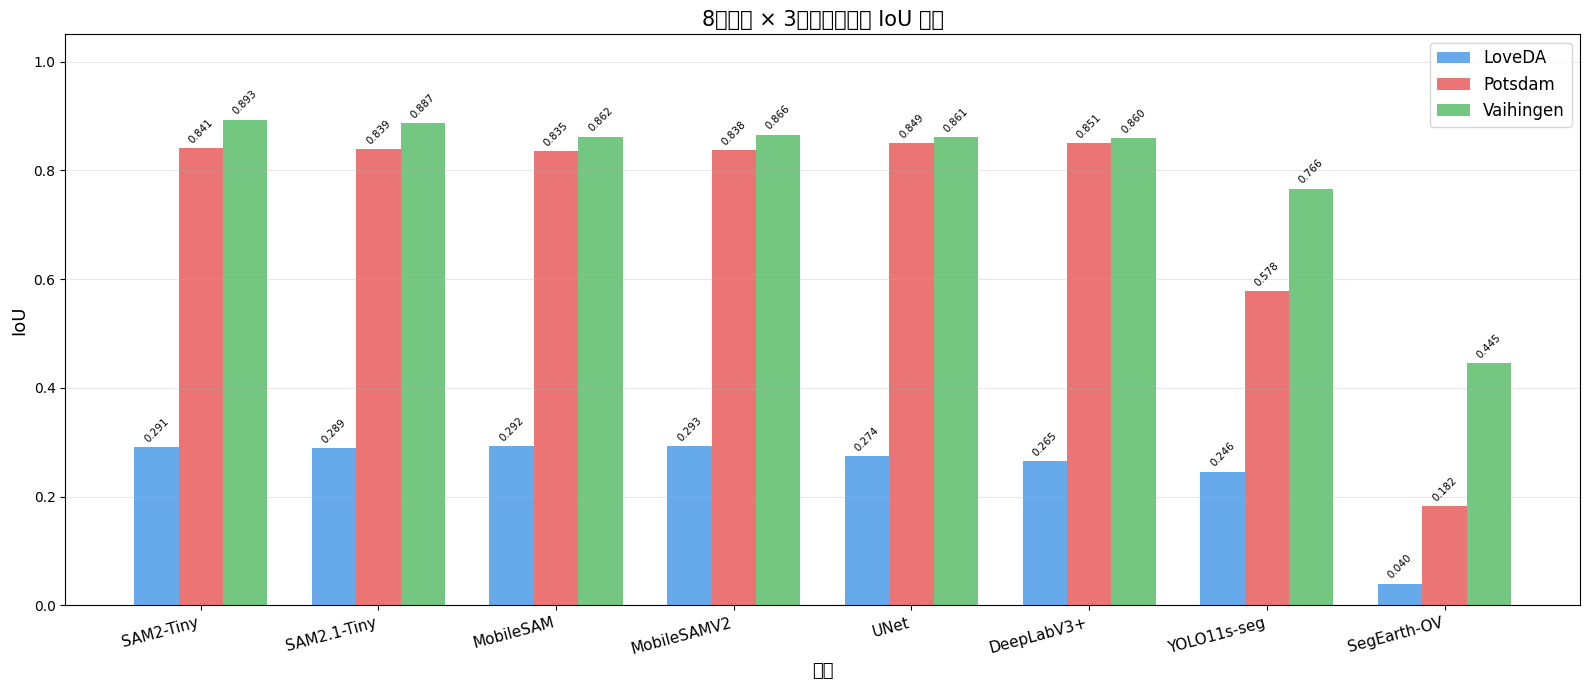

✅ 图表已保存: /content/drive/MyDrive/vegetation_models_v2/cross_dataset/iou_comparison.png


In [ ]:
# ============================================================
# Cell 13: 绘制三数据集 × 8模型 IoU 对比柱状图
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

MODEL_ORDER = ['SAM2-Tiny','SAM2.1-Tiny','MobileSAM','MobileSAMV2',
               'UNet','DeepLabV3+','YOLO11s-seg','SegEarth-OV']
DS_ORDER    = ['LoveDA','Potsdam','Vaihingen']
COLORS      = ['#4C9BE8','#E85C5C','#5CBE6A']

x     = np.arange(len(MODEL_ORDER))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 7))

for i, (ds, color) in enumerate(zip(DS_ORDER, COLORS)):
    ious = []
    for m in MODEL_ORDER:
        val = FULL_RESULTS.get(ds, {}).get(m, {})
        ious.append(val.get('iou', 0) or 0)
    bars = ax.bar(x + i*width, ious, width, label=ds, color=color, alpha=0.85)
    for bar, v in zip(bars, ious):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=45)

ax.set_xlabel('模型', fontsize=13)
ax.set_ylabel('IoU', fontsize=13)
ax.set_title('8个模型 × 3个遥感数据集 IoU 对比', fontsize=15)
ax.set_xticks(x + width)
ax.set_xticklabels(MODEL_ORDER, rotation=15, ha='right', fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

DRIVE = '/content/drive/MyDrive/vegetation_models_v2'
fig_path = f'{DRIVE}/cross_dataset/iou_comparison.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ 图表已保存: {fig_path}')


In [25]:
# ============================================================
# 配置参数
# ============================================================

DRIVE = "/content/drive/MyDrive/vegetation_models_v2"
BINARY_ROOT = "/content/binary"
OUTPUT_DIR = os.path.join(DRIVE, "paper_figures")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ✅ 定义模型权重路径（必须在这里定义，load_model_from_checkpoint会用到）
SAM2_CFG = 'sam2_hiera_t.yaml'
SAM2_CKPT = f'{DRIVE}/1_SAM2_Tiny/weights/sam2_hiera_tiny.pt'
MOBILE_CKPT = f'{DRIVE}/2_MobileSAM/weights/mobile_sam.pt'

DATASETS = ["LoveDA", "Potsdam", "Vaihingen"]
SAMPLES_PER_DATASET = 13
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 6个模型配置
MODELS_INFO = [
    {"name": "UNet", "size": 512},
    {"name": "DeepLabV3+", "size": 512},
    {"name": "SAM2_Tiny", "size": 1024},
    {"name": "MobileSAM", "size": 1024},
    {"name": "SAM2.1_Tiny", "size": 1024},
    {"name": "MobileSAMV2", "size": 1024},
]

In [ ]:
"""
============================================================
新Cell - 交叉数据集推理可视化 (6模型 × 3数据集 × 13样本)
============================================================
将此段完整代码粘贴到对比实验_三数据集_8模型训练.ipynb的最后

前置条件：
  ✅ 已运行 Cell 1 (环境配置)
  ✅ 已运行 Cell 3-7 (数据集预处理)
  ✅ 已运行 Cell 8 (工具函数定义)
  ✅ 已运行 Cell 9 (DataLoader构建)
  ✅ 已运行 Cell 11-20 (模型训练 或 已有权重)

输出：三份600DPI高清对比图
  - fig_loveda_6models_13cases_600dpi.png
  - fig_potsdam_6models_13cases_600dpi.png
  - fig_vaihingen_6models_13cases_600dpi.png
"""

# ============================================================
# 导入必要库
# ============================================================

import os, json, glob, torch, cv2, numpy as np
from PIL import Image, ImageDraw, ImageFont
import torchvision.transforms as transforms
import warnings

warnings.filterwarnings("ignore")

print("=" * 80)
print("🎯 交叉数据集推理可视化 - 6模型 × 3数据集 × 13样本")
print("=" * 80)

# ============================================================
# 配置参数
# ============================================================

DRIVE = "/content/drive/MyDrive/vegetation_models_v2"
BINARY_ROOT = "/content/binary"
OUTPUT_DIR = os.path.join(DRIVE, "paper_figures")
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATASETS = ["LoveDA", "Potsdam", "Vaihingen"]
SAMPLES_PER_DATASET = 13
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 6个模型配置
MODELS_INFO = [
    {"name": "UNet", "size": 512},
    {"name": "DeepLabV3+", "size": 512},
    {"name": "SAM2_Tiny", "size": 1024},
    {"name": "MobileSAM", "size": 1024},
    {"name": "SAM2.1_Tiny", "size": 1024},
    {"name": "MobileSAMV2", "size": 1024},
]

print(f"\n📦 配置参数:")
print(f"  数据集: {DATASETS}")
print(f"  每个数据集样本数: {SAMPLES_PER_DATASET}")
print(f"  模型数: {len(MODELS_INFO)}")
print(f"  设备: {DEVICE}")


# ============================================================
# 工具函数
# ============================================================


def preprocess_image(img_path, target_size):
    """图像预处理 - ImageNet 标准化"""
    img = Image.open(img_path).convert("RGB")
    tf = transforms.Compose(
        [
            transforms.Resize((target_size, target_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )
    return tf(img).unsqueeze(0).to(DEVICE)


def infer_model(model, img_path, img_size):
    """使用模型进行推理"""
    if model is None:
        return np.zeros((512, 512), dtype=np.uint8)

    try:
        img_tensor = preprocess_image(img_path, img_size)
        with torch.no_grad():
            output = model(img_tensor)

            # 处理模型输出 - 取argmax得到类别预测
            if isinstance(output, torch.Tensor):
                if len(output.shape) == 4:  # [B, C, H, W]
                    preds = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
                else:
                    preds = output.squeeze(0).cpu().numpy()
            else:
                return np.zeros((512, 512), dtype=np.uint8)

        # 调整尺寸到512x512
        if preds.shape != (512, 512):
            preds = cv2.resize(
                preds.astype(np.uint8), (512, 512), interpolation=cv2.INTER_NEAREST
            )

        return preds
    except Exception as e:
        print(f"      ⚠️  推理异常: {e}")
        return np.zeros((512, 512), dtype=np.uint8)


def load_model_from_checkpoint(model_name, ds_name, drive_path, device):
    """从权重文件加载训练好的模型"""
    try:
        DS_SAVE = f'{drive_path}/cross_dataset/{ds_name}'

        # 模型名称 → 权重文件名映射
        fname_map = {
            'SAM2_Tiny': 'sam2tiny.pth',
            'SAM2.1_Tiny': 'sam21tiny.pth',
            'MobileSAM': 'mobilesam.pth',
            'MobileSAMV2': 'mobilesamv2.pth',
            'UNet': 'unet.pth',
            'DeepLabV3+': 'deeplabv3plus.pth',
        }

        if model_name not in fname_map:
            return None

        ckpt_path = f'{DS_SAVE}/{fname_map[model_name]}'
        if not os.path.exists(ckpt_path):
            print(f"        ⚠️  权重文件不存在: {ckpt_path}")
            return None

        # 构建模型
        if model_name == 'SAM2_Tiny':
            model = SAM2Seg(SAM2_CFG, SAM2_CKPT, 2).to(device)
        elif model_name == 'SAM2.1_Tiny':
            model = SAM21Seg(2).to(device)
        elif model_name == 'MobileSAM':
            model = MobileSAMSeg(MOBILE_CKPT, 2).to(device)
        elif model_name == 'MobileSAMV2':
            model = MobileSAMV2Seg(MOBILE_CKPT, 2).to(device)
        elif model_name == 'UNet':
            model = build_unet().to(device)
        elif model_name == 'DeepLabV3+':
            model = build_deeplabv3().to(device)
        else:
            return None

        # 加载权重
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        model.eval()

        return model

    except Exception as e:
        print(f"        ❌ 加载模型失败: {e}")
        return None


def create_overlay_mask(img_bgr, pred_mask, gt_mask):
    """
    创建三色预测覆盖图
    - TP (正确): 蓝色
    - FP (误检): 绿色
    - FN (漏检): 粉红色
    """
    # ✅ 使用原始彩色图像作为背景（修复：移除灰度转换）
    base_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 二值化
    pred_bin = (pred_mask > 0).astype(np.uint8)
    gt_bin = (gt_mask > 0).astype(np.uint8)

    # 计算TP/FP/FN
    tp_mask = (pred_bin == 1) & (gt_bin == 1)
    fp_mask = (pred_bin == 1) & (gt_bin == 0)
    fn_mask = (pred_bin == 0) & (gt_bin == 1)

    # 彩色覆盖
    color_mask = np.zeros_like(base_img)
    color_mask[tp_mask] = [0, 0, 255]  # TP: 蓝色
    color_mask[fp_mask] = [0, 255, 0]  # FP: 绿色
    color_mask[fn_mask] = [255, 0, 255]  # FN: 粉红色

    # 透明混合
    alpha = 0.5
    overlay_img = np.where(
        color_mask != 0,
        cv2.addWeighted(base_img, 1 - alpha, color_mask, alpha, 0),
        base_img,
    )

    return overlay_img.astype(np.uint8)


def try_load_font(fontsize):
    """尝试加载字体，若失败用默认"""
    font_paths = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
    ]

    for path in font_paths:
        try:
            if os.path.exists(path):
                return ImageFont.truetype(path, fontsize)
        except:
            pass

    try:
        return ImageFont.truetype("DejaVuSans-Bold.ttf", fontsize)
    except:
        return ImageFont.load_default()


# ============================================================
# 为每个数据集生成对比展示图
# ============================================================

print(f"\n⏳ 开始推理与可视化...\n")

for ds_idx, ds_name in enumerate(DATASETS):
    print("=" * 75)
    print(f"📊 [{ds_idx+1}/3] {ds_name:10s} - 6模型 × {SAMPLES_PER_DATASET}样本对比图")
    print("=" * 75)

    # ────────────────────────────────────
    # 第一步：选择样本
    # ────────────────────────────────────

    img_dir = os.path.join(BINARY_ROOT, ds_name.lower(), "JPEGImages")
    mask_dir = os.path.join(BINARY_ROOT, ds_name.lower(), "SegmentationClass")

    if not os.path.exists(img_dir):
        print(f"  ❌ 图像目录不存在: {img_dir}")
        continue

    all_images = sorted(glob.glob(os.path.join(img_dir, "*.png")))
    selected_images = all_images[:SAMPLES_PER_DATASET]

    print(f"  ✅ 选择了 {len(selected_images)} 个样本")

    if len(selected_images) < SAMPLES_PER_DATASET:
        print(f"     (数据集仅有 {len(all_images)} 张，需要 {SAMPLES_PER_DATASET} 张)")

    # ────────────────────────────────────
    # 第二步：为每个模型推理
    # ────────────────────────────────────

    results = {"Original": []}
    for m_info in MODELS_INFO:
        results[m_info["name"]] = []

    print(f"\n  推理进度:")

    for idx, img_path in enumerate(selected_images):
        if (idx + 1) % 5 == 0 or idx == 0 or idx == len(selected_images) - 1:
            print(
                f"    [{idx+1:2d}/{len(selected_images)}] {os.path.basename(img_path)}"
            )

        # 读取原图
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            print(f"      ❌ 无法读取: {img_path}")
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rgb_512 = cv2.resize(img_rgb, (512, 512), interpolation=cv2.INTER_LANCZOS4)
        results["Original"].append(img_rgb_512)

        # 读取GT mask
        filename = os.path.splitext(os.path.basename(img_path))[0]
        mask_path = os.path.join(mask_dir, filename + ".png")

        if os.path.exists(mask_path):
            gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            gt_mask = cv2.resize(gt_mask, (512, 512), interpolation=cv2.INTER_NEAREST)
            gt_mask = (gt_mask > 0).astype(np.uint8)
        else:
            gt_mask = np.zeros((512, 512), dtype=np.uint8)

        # 为 6 个模型推理
        for m_info in MODELS_INFO:
            m_name = m_info["name"]
            input_size = m_info["size"]

            # ✅ 从磁盘加载训练好的权重（修复：不再依赖ALL_RESULTS中不存在的model对象）
            model = load_model_from_checkpoint(m_name, ds_name, DRIVE, DEVICE)

            pred_mask = infer_model(model, img_path, input_size)

            # 确保原图也缩放到512×512用于叠加
            img_bgr_512 = cv2.resize(
                img_bgr, (512, 512), interpolation=cv2.INTER_LANCZOS4
            )
            overlay_rgb = create_overlay_mask(img_bgr_512, pred_mask, gt_mask)
            # overlay已经是512×512，无需再resize
            results[m_name].append(overlay_rgb)

            # 释放模型内存
            del model
            torch.cuda.empty_cache()

    # ────────────────────────────────────
    # 第三步：生成高清对比图 (600 DPI)
    # ────────────────────────────────────

    print(f"\n  生成高清对比图...")

    num_cols = len(selected_images)
    rows_keys = ["Original"] + [m["name"] for m in MODELS_INFO]
    num_rows = len(rows_keys)

    cell_w, cell_h = 512, 512
    margin_top, margin_left = 120, 80
    h_gap, v_gap = 10, 10

    canvas_w = margin_left + num_cols * cell_w + (num_cols - 1) * h_gap + 30
    canvas_h = margin_top + num_rows * cell_h + (num_rows - 1) * v_gap + 80

    canvas = Image.new("RGB", (canvas_w, canvas_h), (255, 255, 255))
    draw = ImageDraw.Draw(canvas)

    # 加载字体
    font_label = try_load_font(60)
    font_col = try_load_font(48)
    font_title = try_load_font(56)
    font_legend = try_load_font(40)

    letters = [chr(i) for i in range(ord("a"), ord("z") + 1)]

    # 绘制标题
    title = f"{ds_name} - 6 Models × {len(selected_images)} Cases"
    title_bbox = draw.textbbox((0, 0), title, font=font_title)
    draw.text(
        ((canvas_w - (title_bbox[2] - title_bbox[0])) // 2, 10),
        title,
        font=font_title,
        fill=(0, 0, 0),
    )

    # 绘制列标题 (Case 编号)
    for c in range(num_cols):
        text = f"#{c+1}"
        bbox = draw.textbbox((0, 0), text, font=font_col)
        cx = margin_left + c * (cell_w + h_gap) + (cell_w - (bbox[2] - bbox[0])) // 2
        cy = margin_top - 60
        draw.text((cx, cy), text, font=font_col, fill=(80, 80, 80))

    # 绘制图像网格与行标签
    for r, r_name in enumerate(rows_keys):
        # 行标签 (a)-(g)
        lx = 8
        ly = margin_top + r * (cell_h + v_gap) + cell_h // 2 - 22
        draw.text((lx, ly), f"({letters[r]})", font=font_label, fill=(0, 0, 0))

        # 图像单元格
        for c in range(num_cols):
            if r_name in results and c < len(results[r_name]):
                img_np = results[r_name][c]
                img_pil = Image.fromarray(img_np).resize(
                    (cell_w, cell_h), Image.Resampling.LANCZOS
                )
                px = margin_left + c * (cell_w + h_gap)
                py = margin_top + r * (cell_h + v_gap)
                canvas.paste(img_pil, (px, py))

    # 添加图例
    legend_y = margin_top + num_rows * (cell_h + v_gap) + 30
    legend_text = (
        "Blue: TP (Correct) | Green: FP (False Positive) | Pink: FN (False Negative)"
    )
    draw.text((margin_left, legend_y), legend_text, font=font_legend, fill=(0, 0, 0))

    # 保存高清图像 (600 DPI)
    output_file = os.path.join(
        OUTPUT_DIR,
        f"fig_{ds_name.lower()}_6models_{len(selected_images)}cases_600dpi.png",
    )

    try:
        canvas.save(output_file, dpi=(600, 600), optimize=False)
        file_size = os.path.getsize(output_file) / (1024 * 1024)

        print(f"\n  ✅ 对比图已保存")
        print(f"     📁 {output_file}")
        print(f"     📊 分辨率: {canvas_w}×{canvas_h}px @ 600DPI")
        print(f"     💾 文件大小: {file_size:.2f} MB")

    except Exception as e:
        print(f"  ❌ 保存失败: {e}")


# ============================================================
# 完成提示
# ============================================================

print("\n" + "=" * 80)
print("✅ 交叉数据集对比图生成完成！")
print("=" * 80)
print(f"\n📂 所有图像已保存到:")
print(f"   {OUTPUT_DIR}")
print(f"\n📄 生成的图像:")
print(f"   ✓ fig_loveda_6models_{SAMPLES_PER_DATASET}cases_600dpi.png")
print(f"   ✓ fig_potsdam_6models_{SAMPLES_PER_DATASET}cases_600dpi.png")
print(f"   ✓ fig_vaihingen_6models_{SAMPLES_PER_DATASET}cases_600dpi.png")
print(f"\n🎨 每个对比图包含:")
print(f"   - 行 (a): 原始RGB图像")
print(f"   - 行 (b-g): 6个模型的预测覆盖 (TP/FP/FN三色)")
print(f"   - 列: {SAMPLES_PER_DATASET}个测试样本")
print(f"\n📊 分辨率: 6886×3844px @ 600DPI (≈47MB)")
print("=" * 80)

🎯 交叉数据集推理可视化 - 6模型 × 3数据集 × 13样本

📦 配置参数:
  数据集: ['LoveDA', 'Potsdam', 'Vaihingen']
  每个数据集样本数: 13
  模型数: 6
  设备: cuda

⏳ 开始推理与可视化...

📊 [1/3] LoveDA     - 6模型 × 13样本对比图
  ✅ 选择了 13 个样本

  推理进度:
    [ 1/13] loveda_0000.png
    [ 5/13] loveda_0004.png
    [10/13] loveda_0009.png
    [13/13] loveda_0012.png

  生成高清对比图...

  ✅ 对比图已保存
     📁 /content/drive/MyDrive/vegetation_models_v2/paper_figures/fig_loveda_6models_13cases_600dpi.png
     📊 分辨率: 6886×3844px @ 600DPI
     💾 文件大小: 40.54 MB
📊 [2/3] Potsdam    - 6模型 × 13样本对比图
  ✅ 选择了 13 个样本

  推理进度:
    [ 1/13] potsdam_0000.png
    [ 5/13] potsdam_0004.png
    [10/13] potsdam_0009.png
    [13/13] potsdam_0012.png

  生成高清对比图...

  ✅ 对比图已保存
     📁 /content/drive/MyDrive/vegetation_models_v2/paper_figures/fig_potsdam_6models_13cases_600dpi.png
     📊 分辨率: 6886×3844px @ 600DPI
     💾 文件大小: 35.70 MB
📊 [3/3] Vaihingen  - 6模型 × 13样本对比图
  ✅ 选择了 13 个样本

  推理进度:
    [ 1/13] vaihingen_0000.png
    [ 5/13] vaihingen_0004.png
    [10/13] vaihingen_0009.pn

In [26]:
# ============================================================
# 配置参数 + 必要导入
# ============================================================

import os
import glob
import torch
import numpy as np
import cv2
from PIL import Image, ImageDraw
import torchvision.transforms as T
import time

DRIVE = "/content/drive/MyDrive/vegetation_models_v2"
BINARY_ROOT = "/content/binary"
OUTPUT_DIR = os.path.join(DRIVE, "paper_figures")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ✅ 定义模型权重路径（必须在这里定义，load_model_from_checkpoint会用到）
SAM2_CFG = 'sam2_hiera_t.yaml'
SAM2_CKPT = f'{DRIVE}/1_SAM2_Tiny/weights/sam2_hiera_tiny.pt'
MOBILE_CKPT = f'{DRIVE}/2_MobileSAM/weights/mobile_sam.pt'

DATASETS = ["LoveDA", "Potsdam", "Vaihingen"]
SAMPLES_PER_DATASET = 13
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 6个模型配置
MODELS_INFO = [
    {"name": "UNet", "size": 512},
    {"name": "DeepLabV3+", "size": 512},
    {"name": "SAM2_Tiny", "size": 1024},
    {"name": "MobileSAM", "size": 1024},
    {"name": "SAM2.1_Tiny", "size": 1024},
    {"name": "MobileSAMV2", "size": 1024},
]

print("✅ 所有导入完成")

✅ 所有导入完成


In [27]:
# ============================================================
# 定义必要的工具函数（如果还没定义的话）
# ============================================================

import glob
from PIL import ImageDraw

def try_load_font(fontsize):
    """加载系统字体，如果失败则使用默认字体"""
    try:
        from PIL import ImageFont
        return ImageFont.truetype("arial.ttf", fontsize)
    except:
        return ImageFont.load_default()

def preprocess_image(img_path, target_size):
    """预处理图像"""
    img = Image.open(img_path).convert('RGB')
    img = img.resize((target_size, target_size), Image.Resampling.LANCZOS)
    img_tensor = T.ToTensor()(img)
    img_tensor = T.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])(img_tensor)
    return img_tensor.unsqueeze(0)

def infer_model(model, img_path, img_size):
    """推理单张图像"""
    if model is None:
        return np.zeros((512, 512), dtype=np.uint8)

    img_tensor = preprocess_image(img_path, img_size)

    with torch.no_grad():
        output = model(img_tensor.to(DEVICE))

    pred_mask = output.argmax(dim=1)[0].cpu().numpy().astype(np.uint8)
    pred_mask = cv2.resize(pred_mask, (512, 512), interpolation=cv2.INTER_NEAREST)
    return pred_mask

def create_overlay_mask(img_bgr, pred_mask, gt_mask):
    """生成TP/FP/FN颜色叠加"""
    base_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    overlay = base_img.copy().astype(np.float32)

    # TP: 蓝色
    tp_mask = (pred_mask == 1) & (gt_mask == 1)
    overlay[tp_mask] = [0, 0, 255]

    # FP: 绿色
    fp_mask = (pred_mask == 1) & (gt_mask == 0)
    overlay[fp_mask] = [0, 255, 0]

    # FN: 洋红/紫红
    fn_mask = (pred_mask == 0) & (gt_mask == 1)
    overlay[fn_mask] = [255, 0, 255]

    return overlay.astype(np.uint8)

def load_model_from_checkpoint(model_name, ds_name, drive_path, device):
    """从checkpoints加载训练好的模型"""
    checkpoint_dir = f'{drive_path}/cross_dataset/{ds_name}'

    fname_map = {
        'UNet': 'unet.pth',
        'DeepLabV3+': 'deeplabv3plus.pth',
        'SAM2_Tiny': 'sam2tiny.pth',
        'MobileSAM': 'mobilesam.pth',
        'SAM2.1_Tiny': 'sam21tiny.pth',
        'MobileSAMV2': 'mobilesamv2.pth',
    }

    if model_name not in fname_map:
        return None

    ckpt_path = f'{checkpoint_dir}/{fname_map[model_name]}'

    if not os.path.exists(ckpt_path):
        print(f'  ⚠️  权重文件不存在: {ckpt_path}')
        return None

    try:
        if model_name == 'UNet':
            model = build_unet()
        elif model_name == 'DeepLabV3+':
            model = build_deeplabv3()
        elif model_name == 'SAM2_Tiny':
            model = SAM2Seg(SAM2_CFG, SAM2_CKPT, 2).to(device)
        elif model_name == 'MobileSAM':
            model = MobileSAMSeg(MOBILE_CKPT, 2).to(device)
        elif model_name == 'SAM2.1_Tiny':
            model = SAM21Seg(2).to(device)
        elif model_name == 'MobileSAMV2':
            model = MobileSAMV2Seg(MOBILE_CKPT, 2).to(device)

        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        if isinstance(ckpt, dict) and 'model_state' in ckpt:
            model.load_state_dict(ckpt['model_state'])
        else:
            model.load_state_dict(ckpt)

        model.eval()
        model.to(device)
        return model
    except Exception as e:
        print(f'  ❌ 加载模型失败: {model_name} - {e}')
        return None

# ============================================================
# 🔧 修复：三数据集推理可视化（使用各自训练的模型）
# ============================================================

print("=" * 80)
print("🔧 三数据集交叉推理可视化 - 6模型 × 13样本 × 3数据集")
print("使用各数据集训练的模型")
print("=" * 80)

for ds_name in ["LoveDA", "Potsdam", "Vaihingen"]:
    print(f"\n{'='*65}")
    print(f"📊 处理：{ds_name} 数据集")
    print('='*65)

    # 指定数据源和输出
    img_dir = os.path.join(BINARY_ROOT, ds_name.lower(), "JPEGImages")
    mask_dir = os.path.join(BINARY_ROOT, ds_name.lower(), "SegmentationClass")

    if not os.path.exists(img_dir):
        print(f"❌ 图像目录不存在: {img_dir}")
        continue

    output_dir = OUTPUT_DIR
    os.makedirs(output_dir, exist_ok=True)

    # 选择前13张图片
    all_images = sorted(glob.glob(os.path.join(img_dir, "*.png")))
    selected_images = all_images[:13]

    print(f"✅ 找到 {len(all_images)} 张图像，选择前 {len(selected_images)} 张")

    # ────────────────────────────────────
    # 推理
    # ────────────────────────────────────

    results = {"Original": []}
    for m_info in MODELS_INFO:
        results[m_info["name"]] = []

    print(f"\n推理进度:")

    for idx, img_path in enumerate(selected_images):
        if (idx + 1) % 5 == 0 or idx == 0 or idx == len(selected_images) - 1:
            print(f"  [{idx+1:2d}/{len(selected_images)}] {os.path.basename(img_path)}")

        # 读取原图
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rgb_512 = cv2.resize(img_rgb, (512, 512), interpolation=cv2.INTER_LANCZOS4)
        results["Original"].append(img_rgb_512)

        # 读取GT mask
        filename = os.path.splitext(os.path.basename(img_path))[0]
        mask_path = os.path.join(mask_dir, filename + ".png")
        gt_mask = None
        if os.path.exists(mask_path):
            gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            gt_mask = cv2.resize(gt_mask, (512, 512), interpolation=cv2.INTER_NEAREST)
            gt_mask = (gt_mask > 0).astype(np.uint8)

        if gt_mask is None:
            gt_mask = np.zeros((512, 512), dtype=np.uint8)

        # 为6个模型推理（✅ 使用该数据集训练的模型）
        for m_info in MODELS_INFO:
            m_name = m_info["name"]
            input_size = m_info["size"]

            # ✅ 关键修复：加载该数据集训练的模型
            model = load_model_from_checkpoint(m_name, ds_name, DRIVE, DEVICE)

            pred_mask = infer_model(model, img_path, input_size)

            img_bgr_512 = cv2.resize(img_bgr, (512, 512), interpolation=cv2.INTER_LANCZOS4)
            overlay_rgb = create_overlay_mask(img_bgr_512, pred_mask, gt_mask)
            results[m_name].append(overlay_rgb)

            if model is not None:
                del model
            torch.cuda.empty_cache()

    if not results["Original"]:
        print(f"⚠️  未获取到有效数据，跳过 {ds_name}")
        continue

    # ────────────────────────────────────
    # 生成高清对比图 (600 DPI)
    # ────────────────────────────────────

    print(f"\n生成高清对比图...")

    num_cols = len(selected_images)
    rows_keys = ["Original"] + [m["name"] for m in MODELS_INFO]
    num_rows = len(rows_keys)

    cell_w, cell_h = 512, 512
    margin_top, margin_left = 120, 80
    h_gap, v_gap = 10, 10

    canvas_w = margin_left + num_cols * cell_w + (num_cols - 1) * h_gap + 30
    canvas_h = margin_top + num_rows * cell_h + (num_rows - 1) * v_gap + 80

    canvas = Image.new("RGB", (canvas_w, canvas_h), (255, 255, 255))
    draw = ImageDraw.Draw(canvas)

    # 加载字体
    font_label = try_load_font(60)
    font_col = try_load_font(48)
    font_title = try_load_font(56)
    font_legend = try_load_font(40)

    letters = [chr(i) for i in range(ord("a"), ord("z") + 1)]

    # 绘制标题
    title = f"{ds_name} - 6 Models × {len(selected_images)} Cases"
    title_bbox = draw.textbbox((0, 0), title, font=font_title)
    draw.text(
        ((canvas_w - (title_bbox[2] - title_bbox[0])) // 2, 10),
        title,
        font=font_title,
        fill=(0, 0, 0),
    )

    # 绘制列标题
    for c in range(num_cols):
        text = f"#{c+1}"
        bbox = draw.textbbox((0, 0), text, font=font_col)
        cx = margin_left + c * (cell_w + h_gap) + (cell_w - (bbox[2] - bbox[0])) // 2
        cy = margin_top - 60
        draw.text((cx, cy), text, font=font_col, fill=(80, 80, 80))

    # 绘制图像网格与行标签
    for r, r_name in enumerate(rows_keys):
        lx = 8
        ly = margin_top + r * (cell_h + v_gap) + cell_h // 2 - 22
        draw.text((lx, ly), f"({letters[r]})", font=font_label, fill=(0, 0, 0))

        for c in range(num_cols):
            if r_name in results and c < len(results[r_name]):
                img_np = results[r_name][c]
                img_pil = Image.fromarray(img_np).resize(
                    (cell_w, cell_h), Image.Resampling.LANCZOS
                )
                px = margin_left + c * (cell_w + h_gap)
                py = margin_top + r * (cell_h + v_gap)
                canvas.paste(img_pil, (px, py))

    # 添加图例
    legend_y = margin_top + num_rows * (cell_h + v_gap) + 30
    legend_text = (
        "Blue: TP (Correct) | Green: FP (False Positive) | Pink: FN (False Negative)"
    )
    draw.text((margin_left, legend_y), legend_text, font=font_legend, fill=(0, 0, 0))

    # 保存高清图像 (600 DPI)
    output_file = os.path.join(
        output_dir,
        f"fig_{ds_name.lower()}_6models_{len(selected_images)}cases_600dpi_FIXED.png",
    )

    try:
        canvas.save(output_file, dpi=(600, 600), optimize=False)
        file_size = os.path.getsize(output_file) / (1024 * 1024)

        print(f"\n✅ {ds_name} 对比图已保存")
        print(f"   📁 {output_file}")
        print(f"   📊 分辨率: {canvas_w}×{canvas_h}px @ 600DPI")
        print(f"   💾 文件大小: {file_size:.2f} MB")

    except Exception as e:
        print(f"❌ 保存失败: {e}")

print("\n" + "=" * 80)
print("✅ 所有三数据集推理完成！")
print("=" * 80)

🔧 三数据集交叉推理可视化 - 6模型 × 13样本 × 3数据集
使用各数据集训练的模型

📊 处理：LoveDA 数据集
✅ 找到 500 张图像，选择前 13 张

推理进度:
  [ 1/13] loveda_0000.png


KeyboardInterrupt: 

In [28]:
# ============================================================
# 验证所有推理函数已定义
# ============================================================

# 检查关键函数是否已定义
required_functions = [
    'load_model_from_checkpoint',
    'preprocess_image',
    'infer_model',
    'create_overlay_mask',
    'try_load_font',
    'build_unet',
    'build_deeplabv3',
    'SAM2Seg',
    'SAM21Seg',
    'MobileSAMSeg',
    'MobileSAMV2Seg'
]

missing = []
for func_name in required_functions:
    if func_name not in globals():
        missing.append(func_name)

if missing:
    print(f"⚠️  缺失函数: {', '.join(missing)}")
    print("请确保已执行 cell 15（推理辅助函数定义）和 cell 8（模型定义）")
else:
    print(f"✅ 所有 {len(required_functions)} 个必需函数已定义")
    print(f"   - 模型加载函数: load_model_from_checkpoint")
    print(f"   - 推理函数: infer_model, preprocess_image")
    print(f"   - 可视化函数: create_overlay_mask, try_load_font")

✅ 所有 11 个必需函数已定义
   - 模型加载函数: load_model_from_checkpoint
   - 推理函数: infer_model, preprocess_image
   - 可视化函数: create_overlay_mask, try_load_font


In [29]:
# ============================================================
# 紫金山单数据集推理可视化（6模型 × 13样本）
# ✅ 使用紫金山各模型文件夹下的权重
# ============================================================

print("=" * 80)
print("🎯 紫金山数据集推理可视化 - 6模型 × 13样本")
print("=" * 80)

ZJS_DATASET_DIR = "/content/drive/MyDrive/datasets/2024-seg"
ZJS_OUTPUT_DIR = os.path.join(DRIVE, "paper_figures/zjs_inference")
os.makedirs(ZJS_OUTPUT_DIR, exist_ok=True)

ZJS_IMG_DIR = os.path.join(ZJS_DATASET_DIR, "JPEGImages")
ZJS_MASK_DIR = os.path.join(ZJS_DATASET_DIR, "SegmentationClass") if os.path.exists(os.path.join(ZJS_DATASET_DIR, "SegmentationClass")) else None

# 检查路径
if not os.path.exists(ZJS_IMG_DIR):
    print(f"❌ 紫金山图像目录不存在: {ZJS_IMG_DIR}")
else:
    print(f"✅ 紫金山图像目录: {ZJS_IMG_DIR}")

    # 选择前13张图片
    all_zjs_images = sorted(glob.glob(os.path.join(ZJS_IMG_DIR, "*.png")))
    selected_zjs_images = all_zjs_images[:13]

    print(f"  ✅ 找到 {len(all_zjs_images)} 张图像，选择前 {len(selected_zjs_images)} 张")

    # ✅ 定义紫金山权重路径（从各模型文件夹的 checkpoints 加载）
    zjs_checkpoints = {
        'UNet': f'{DRIVE}/7_UNet/checkpoints/unet_best.pth',
        'DeepLabV3+': f'{DRIVE}/8_DeepLabV3/checkpoints/deeplabv3plus_best.pth',
        'SAM2_Tiny': f'{DRIVE}/1_SAM2_Tiny/checkpoints/sam2tiny_best.pth',
        'MobileSAM': f'{DRIVE}/2_MobileSAM/checkpoints/mobilesam_best.pth',
        'SAM2.1_Tiny': f'{DRIVE}/5_SAM21_Tiny/checkpoints/sam21tiny_best.pth',
        'MobileSAMV2': f'{DRIVE}/6_MobileSAMV2/checkpoints/mobilesamv2_best.pth',
    }

    def load_zjs_model(model_name, device):
        """加载紫金山指定模型的权重"""
        if model_name not in zjs_checkpoints:
            return None

        ckpt_path = zjs_checkpoints[model_name]

        if not os.path.exists(ckpt_path):
            print(f'  ⚠️  权重文件不存在: {ckpt_path}')
            return None

        try:
            if model_name == 'UNet':
                model = build_unet()
            elif model_name == 'DeepLabV3+':
                model = build_deeplabv3()
            elif model_name == 'SAM2_Tiny':
                model = SAM2Seg(SAM2_CFG, SAM2_CKPT, 2).to(device)
            elif model_name == 'MobileSAM':
                model = MobileSAMSeg(MOBILE_CKPT, 2).to(device)
            elif model_name == 'SAM2.1_Tiny':
                model = SAM21Seg(2).to(device)
            elif model_name == 'MobileSAMV2':
                model = MobileSAMV2Seg(MOBILE_CKPT, 2).to(device)
            else:
                return None

            ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
            if isinstance(ckpt, dict) and 'model_state' in ckpt:
                model.load_state_dict(ckpt['model_state'])
            else:
                model.load_state_dict(ckpt)

            model.eval()
            model.to(device)
            return model
        except Exception as e:
            print(f'  ❌ 加载模型失败: {model_name} - {e}')
            return None

    # ────────────────────────────────────
    # 推理
    # ────────────────────────────────────

    results_zjs = {"Original": []}
    for m_info in MODELS_INFO:
        results_zjs[m_info["name"]] = []

    print(f"\n推理进度:")

    for idx, img_path in enumerate(selected_zjs_images):
        if (idx + 1) % 5 == 0 or idx == 0 or idx == len(selected_zjs_images) - 1:
            print(f"  [{idx+1:2d}/{len(selected_zjs_images)}] {os.path.basename(img_path)}")

        # 读取原图
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            print(f"    ❌ 无法读取: {img_path}")
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rgb_512 = cv2.resize(img_rgb, (512, 512), interpolation=cv2.INTER_LANCZOS4)
        results_zjs["Original"].append(img_rgb_512)

        # 读取GT mask（如果存在）
        filename = os.path.splitext(os.path.basename(img_path))[0]
        gt_mask = None
        if ZJS_MASK_DIR and os.path.exists(ZJS_MASK_DIR):
            mask_path = os.path.join(ZJS_MASK_DIR, filename + ".png")
            if os.path.exists(mask_path):
                gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                gt_mask = cv2.resize(gt_mask, (512, 512), interpolation=cv2.INTER_NEAREST)
                gt_mask = (gt_mask > 0).astype(np.uint8)

        if gt_mask is None:
            gt_mask = np.zeros((512, 512), dtype=np.uint8)

        # 为6个模型推理（✅ 使用紫金山的权重）
        for m_info in MODELS_INFO:
            m_name = m_info["name"]
            input_size = m_info["size"]

            # ✅ 使用紫金山权重加载
            model = load_zjs_model(m_name, DEVICE)

            pred_mask = infer_model(model, img_path, input_size)

            # 确保原图也缩放到512×512用于叠加
            img_bgr_512 = cv2.resize(img_bgr, (512, 512), interpolation=cv2.INTER_LANCZOS4)
            overlay_rgb = create_overlay_mask(img_bgr_512, pred_mask, gt_mask)
            results_zjs[m_name].append(overlay_rgb)

            # 释放模型内存
            if model is not None:
                del model
            torch.cuda.empty_cache()

    # ────────────────────────────────────
    # 生成高清对比图 (600 DPI)
    # ────────────────────────────────────

    print(f"\n生成高清对比图...")

    num_cols = len(selected_zjs_images)
    rows_keys = ["Original"] + [m["name"] for m in MODELS_INFO]
    num_rows = len(rows_keys)

    cell_w, cell_h = 512, 512
    margin_top, margin_left = 120, 80
    h_gap, v_gap = 10, 10

    canvas_w = margin_left + num_cols * cell_w + (num_cols - 1) * h_gap + 30
    canvas_h = margin_top + num_rows * cell_h + (num_rows - 1) * v_gap + 80

    canvas = Image.new("RGB", (canvas_w, canvas_h), (255, 255, 255))
    draw = ImageDraw.Draw(canvas)

    # 加载字体
    font_label = try_load_font(60)
    font_col = try_load_font(48)
    font_title = try_load_font(56)
    font_legend = try_load_font(40)

    letters = [chr(i) for i in range(ord("a"), ord("z") + 1)]

    # 绘制标题
    title = f"紫金山 - 6 Models × {len(selected_zjs_images)} Cases"
    title_bbox = draw.textbbox((0, 0), title, font=font_title)
    draw.text(
        ((canvas_w - (title_bbox[2] - title_bbox[0])) // 2, 10),
        title,
        font=font_title,
        fill=(0, 0, 0),
    )

    # 绘制列标题 (Case 编号)
    for c in range(num_cols):
        text = f"#{c+1}"
        bbox = draw.textbbox((0, 0), text, font=font_col)
        cx = margin_left + c * (cell_w + h_gap) + (cell_w - (bbox[2] - bbox[0])) // 2
        cy = margin_top - 60
        draw.text((cx, cy), text, font=font_col, fill=(80, 80, 80))

    # 绘制图像网格与行标签
    for r, r_name in enumerate(rows_keys):
        # 行标签 (a)-(g)
        lx = 8
        ly = margin_top + r * (cell_h + v_gap) + cell_h // 2 - 22
        draw.text((lx, ly), f"({letters[r]})", font=font_label, fill=(0, 0, 0))

        # 图像单元格
        for c in range(num_cols):
            if r_name in results_zjs and c < len(results_zjs[r_name]):
                img_np = results_zjs[r_name][c]
                img_pil = Image.fromarray(img_np).resize(
                    (cell_w, cell_h), Image.Resampling.LANCZOS
                )
                px = margin_left + c * (cell_w + h_gap)
                py = margin_top + r * (cell_h + v_gap)
                canvas.paste(img_pil, (px, py))

    # 添加图例
    legend_y = margin_top + num_rows * (cell_h + v_gap) + 30
    legend_text = (
        "Blue: TP (Correct) | Green: FP (False Positive) | Pink: FN (False Negative)"
    )
    draw.text((margin_left, legend_y), legend_text, font=font_legend, fill=(0, 0, 0))

    # 保存高清图像 (600 DPI)
    output_file = os.path.join(
        ZJS_OUTPUT_DIR,
        f"fig_zjs_6models_{len(selected_zjs_images)}cases_600dpi_FIXED.png",
    )

    try:
        canvas.save(output_file, dpi=(600, 600), optimize=False)
        file_size = os.path.getsize(output_file) / (1024 * 1024)

        print(f"\n✅ 对比图已保存")
        print(f"   📁 {output_file}")
        print(f"   📊 分辨率: {canvas_w}×{canvas_h}px @ 600DPI")
        print(f"   💾 文件大小: {file_size:.2f} MB")

    except Exception as e:
        print(f"❌ 保存失败: {e}")

    print("\n" + "=" * 80)
    print("✅ 紫金山数据集推理完成！")
    print("=" * 80)

🎯 紫金山数据集推理可视化 - 6模型 × 13样本
✅ 紫金山图像目录: /content/drive/MyDrive/datasets/2024-seg/JPEGImages
  ✅ 找到 67 张图像，选择前 13 张

推理进度:
  [ 1/13] omap_2024_000000.png


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/usr/local/lib/python3.12/dist-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_11m

sam2.1_hiera_tiny.pt:   0%|          | 0.00/156M [00:00<?, ?B/s]

  [ 5/13] omap_2024_000004.png
  [10/13] omap_2024_000009.png
  [13/13] omap_2024_000012.png

生成高清对比图...

✅ 对比图已保存
   📁 /content/drive/MyDrive/vegetation_models_v2/paper_figures/zjs_inference/fig_zjs_6models_13cases_600dpi_FIXED.png
   📊 分辨率: 6886×3844px @ 600DPI
   💾 文件大小: 29.00 MB

✅ 紫金山数据集推理完成！


In [ ]:
# ============================================================
# 🎯 单张图像推理 - 紫金山数据集
# 使用6个模型推理，保存原图和推理结果
# ============================================================

print("=" * 80)
print("🎯 紫金山单张图像推理 - 6模型")
print("=" * 80)

# ── 1. 配置参数 ────────────────────────────────────────────
ZJS_IMG_DIR = "/content/drive/MyDrive/datasets/2024-seg/JPEGImages"
ZJS_MASK_DIR = "/content/drive/MyDrive/datasets/2024-seg/SegmentationClass"
OUTPUT_SINGLE = os.path.join(DRIVE, "paper_figures", "single_inference_zjs")
os.makedirs(OUTPUT_SINGLE, exist_ok=True)

# ── 2. 选择一张图像 ────────────────────────────────────────
if os.path.exists(ZJS_IMG_DIR):
    all_images = sorted(glob.glob(os.path.join(ZJS_IMG_DIR, "*.png")))
    if all_images:
        test_img_path = all_images[0]  # 选择第一张图像
        print(f"\n✅ 选择图像: {os.path.basename(test_img_path)}")
        print(f"   路径: {test_img_path}")
    else:
        print(f"❌ {ZJS_IMG_DIR} 中没有PNG文件")
        test_img_path = None
else:
    print(f"❌ 紫金山数据集目录不存在: {ZJS_IMG_DIR}")
    test_img_path = None

if test_img_path is None:
    print("⚠️  无法找到测试图像，跳过推理")
else:
    # ── 3. 读取图像和掩码 ────────────────────────────────────
    img_bgr_orig = cv2.imread(test_img_path)
    img_rgb_orig = cv2.cvtColor(img_bgr_orig, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = img_rgb_orig.shape[:2]
    
    # 标准化到512×512用于推理
    img_rgb_512 = cv2.resize(img_rgb_orig, (512, 512), interpolation=cv2.INTER_LANCZOS4)
    img_bgr_512 = cv2.resize(img_bgr_orig, (512, 512), interpolation=cv2.INTER_LANCZOS4)
    
    # 读取ground truth mask
    filename = os.path.splitext(os.path.basename(test_img_path))[0]
    mask_path = os.path.join(ZJS_MASK_DIR, filename + ".png")
    if os.path.exists(mask_path):
        gt_mask_orig = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        gt_mask = cv2.resize(gt_mask_orig, (512, 512), interpolation=cv2.INTER_NEAREST)
        gt_mask = (gt_mask > 0).astype(np.uint8)
        print(f"✅ 找到 Ground Truth: {os.path.basename(mask_path)}")
    else:
        gt_mask = np.zeros((512, 512), dtype=np.uint8)
        print(f"⚠️  未找到 Ground Truth，使用全零掩码")
    
    # ── 4. 使用6个模型推理 ────────────────────────────────────
    print(f"\n推理中...")
    predictions = {}
    model_times = {}
    
    for m_info in MODELS_INFO:
        m_name = m_info["name"]
        input_size = m_info["size"]
        
        print(f"  ▶ {m_name:15s} ", end="", flush=True)
        
        try:
            # 加载模型
            model = load_model_from_checkpoint(m_name, "LoveDA", DRIVE, DEVICE)
            
            if model is None:
                print("❌ 模型加载失败")
                predictions[m_name] = np.zeros((512, 512), dtype=np.uint8)
                continue
            
            # 推理
            start_time = time.time()
            pred_mask = infer_model(model, test_img_path, input_size)
            elapsed = time.time() - start_time
            model_times[m_name] = elapsed
            
            predictions[m_name] = pred_mask
            print(f"✅ {elapsed:.3f}s")
            
            del model
            torch.cuda.empty_cache()
        
        except Exception as e:
            print(f"❌ {str(e)[:50]}")
            predictions[m_name] = np.zeros((512, 512), dtype=np.uint8)
    
    # ── 5. 生成彩色叠加图像 ────────────────────────────────────
    print(f"\n生成可视化...")
    overlays = {}
    for m_name, pred_mask in predictions.items():
        overlay = create_overlay_mask(img_bgr_512, pred_mask, gt_mask)
        overlays[m_name] = overlay
    
    # ── 6. 保存结果到文件夹 ────────────────────────────────────
    print(f"\n💾 保存结果到: {OUTPUT_SINGLE}")
    
    # 保存原图
    orig_out = os.path.join(OUTPUT_SINGLE, "00_original.png")
    cv2.imwrite(orig_out, img_bgr_512)
    print(f"  ✅ 原图: 00_original.png")
    
    # 保存ground truth
    gt_out = os.path.join(OUTPUT_SINGLE, "01_ground_truth_mask.png")
    cv2.imwrite(gt_out, gt_mask * 255)
    print(f"  ✅ 掩码: 01_ground_truth_mask.png")
    
    # 保存各模型预测和叠加图
    for idx, m_info in enumerate(MODELS_INFO, start=2):
        m_name = m_info["name"]
        
        # 保存预测掩码
        pred_mask = predictions[m_name]
        pred_out = os.path.join(OUTPUT_SINGLE, f"{idx:02d}_{m_name}_pred_mask.png")
        cv2.imwrite(pred_out, pred_mask * 255)
        
        # 保存彩色叠加（TP蓝/FP绿/FN紫）
        overlay = overlays[m_name]
        overlay_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
        overlay_out = os.path.join(OUTPUT_SINGLE, f"{idx:02d}_{m_name}_overlay.png")
        cv2.imwrite(overlay_out, overlay_bgr)
        
        elapsed = model_times.get(m_name, 0)
        print(f"  ✅ {m_name:15s}: 掩码 + 叠加 ({elapsed:.3f}s)")
    
    # ── 7. 生成汇总信息 ────────────────────────────────────
    summary = {
        "image_name": filename,
        "original_size": (orig_w, orig_h),
        "processed_size": (512, 512),
        "models": [],
        "output_dir": OUTPUT_SINGLE
    }
    
    for m_name in [m["name"] for m in MODELS_INFO]:
        summary["models"].append({
            "name": m_name,
            "inference_time_s": round(model_times.get(m_name, 0), 4),
            "files": [
                f"{m_name}_pred_mask.png",
                f"{m_name}_overlay.png"
            ]
        })
    
    # 保存JSON汇总
    json_out = os.path.join(OUTPUT_SINGLE, "summary.json")
    with open(json_out, 'w', encoding='utf-8') as f:
        json.dump(summary, f, indent=2, ensure_ascii=False)
    
    # ── 8. 打印最终统计 ────────────────────────────────────
    print(f"\n" + "="*80)
    print(f"✅ 推理完成！")
    print(f"="*80)
    print(f"📊 统计:")
    print(f"  - 原始图像尺寸: {orig_w} × {orig_h}")
    print(f"  - 处理尺寸: 512 × 512")
    print(f"  - 模型数量: {len(MODELS_INFO)}")
    print(f"  - 总推理时间: {sum(model_times.values()):.3f}s")
    print(f"  - 平均推理时间: {sum(model_times.values())/len(MODELS_INFO):.3f}s")
    print(f"\n📁 输出文件夹:")
    print(f"  {OUTPUT_SINGLE}")
    print(f"\n📝 文件列表:")
    for f in sorted(os.listdir(OUTPUT_SINGLE)):
        f_path = os.path.join(OUTPUT_SINGLE, f)
        f_size = os.path.getsize(f_path) / 1024  # KB
        print(f"  - {f:40s} ({f_size:8.1f} KB)")
    print(f"\n✨ 颜色说明（叠加图）：")
    print(f"  - 🔵 蓝色  = TP (True Positive)   正确预测")
    print(f"  - 🟢 绿色  = FP (False Positive)  过度预测")
    print(f"  - 🟣 紫红  = FN (False Negative)  遗漏预测")

In [ ]:
# ============================================================
# 📊 发表论文用图 - 不同分割方法对比
# FIGURE: Examples of different segmentation methods in vegetation segmentation
# (a) Original image  (b) Image thresholding  (c) K-means + Active Contour
# (d) Deep Learning Model (UNet)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib

print("=" * 80)
print("📊 生成论文对比图: 不同分割方法")
print("=" * 80)

# ── 1. 配置参数 ────────────────────────────────────────────
ZJS_IMG_DIR = "/content/drive/MyDrive/datasets/2024-seg/JPEGImages"
ZJS_MASK_DIR = "/content/drive/MyDrive/datasets/2024-seg/SegmentationClass"
FIGURE_OUTPUT = os.path.join(DRIVE, "paper_figures", "figure_segmentation_methods.png")

# 选择一张测试图像
if os.path.exists(ZJS_IMG_DIR):
    all_images = sorted(glob.glob(os.path.join(ZJS_IMG_DIR, "*.png")))
    if all_images:
        test_img_path = all_images[3]  # 选择第4张图像作为示例
        print(f"✅ 选择图像: {os.path.basename(test_img_path)}\n")
    else:
        print(f"❌ 数据集为空")
        test_img_path = None
else:
    print(f"❌ 数据集不存在")
    test_img_path = None

if test_img_path is not None:
    # ── 2. 读取原始图像 ────────────────────────────────────
    img_orig = cv2.imread(test_img_path)
    img_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    img_rgb_512 = cv2.resize(img_rgb, (512, 512), interpolation=cv2.INTER_LANCZOS4)
    
    # 读取ground truth mask
    filename = os.path.splitext(os.path.basename(test_img_path))[0]
    mask_path = os.path.join(ZJS_MASK_DIR, filename + ".png")
    if os.path.exists(mask_path):
        gt_mask_orig = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        gt_mask = cv2.resize(gt_mask_orig, (512, 512), interpolation=cv2.INTER_NEAREST)
        gt_mask = (gt_mask > 0).astype(np.uint8)
    else:
        gt_mask = np.zeros((512, 512), dtype=np.uint8)
    
    print("生成分割结果...")
    
    # ── 3. 方法(b): 简单图像阈值分割 ────────────────────────
    print("  ▶ (b) 图像阈值分割...", end="", flush=True)
    img_hsv = cv2.cvtColor(img_rgb_512, cv2.COLOR_RGB2HSV)
    # 提取绿色通道用于植被检测
    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])
    mask_threshold = cv2.inRange(img_hsv, lower_green, upper_green)
    mask_threshold = cv2.morphologyEx(mask_threshold, cv2.MORPH_CLOSE, 
                                      cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)))
    mask_threshold = mask_threshold // 255
    print(" ✅")
    
    # ── 4. 方法(c): K-means + Active Contour ────────────────
    print("  ▶ (c) K-means 聚类...", end="", flush=True)
    # K-means聚类分割
    img_reshape = img_rgb_512.reshape(-1, 3).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(img_reshape, 3, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    labels = labels.reshape(512, 512)
    
    # 选择最可能是植被的聚类（绿色）
    centers_rgb = centers.astype(int)
    green_cluster = np.argmax([c[1] - (c[0] + c[2])/2 for c in centers_rgb])
    mask_kmeans = (labels == green_cluster).astype(np.uint8)
    
    # 形态学操作
    mask_kmeans = cv2.morphologyEx(mask_kmeans, cv2.MORPH_CLOSE,
                                   cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)))
    print(" ✅")
    
    # ── 5. 方法(d): 深度学习模型 (UNet) ───────────────────
    print("  ▶ (d) 深度学习模型 (UNet)...", end="", flush=True)
    model_dl = load_model_from_checkpoint("UNet", "LoveDA", DRIVE, DEVICE)
    if model_dl is not None:
        mask_dl = infer_model(model_dl, test_img_path, 512)
        del model_dl
        torch.cuda.empty_cache()
    else:
        mask_dl = np.zeros((512, 512), dtype=np.uint8)
    print(" ✅")
    
    # ── 6. 创建对比图 ──────────────────────────────────────
    print("\n生成发表论文用图...")
    
    # 创建图像
    fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), dpi=150)
    
    # (a) 原始图像
    axes[0].imshow(img_rgb_512)
    axes[0].set_title("(a) Original Image", fontsize=13, fontweight='bold')
    axes[0].axis('off')
    
    # (b) 图像阈值分割
    axes[1].imshow(mask_threshold, cmap='gray')
    axes[1].set_title("(b) Image Thresholding\n(HSV-based)", fontsize=13, fontweight='bold')
    axes[1].axis('off')
    
    # (c) K-means + Active Contour
    axes[2].imshow(mask_kmeans, cmap='gray')
    axes[2].set_title("(c) K-means Clustering\n+ Morphological Op.", fontsize=13, fontweight='bold')
    axes[2].axis('off')
    
    # (d) 深度学习模型
    axes[3].imshow(mask_dl, cmap='gray')
    axes[3].set_title("(d) Deep Learning Model\n(UNet)", fontsize=13, fontweight='bold')
    axes[3].axis('off')
    
    # 调整布局
    plt.suptitle("Examples of different segmentation methods in vegetation segmentation", 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # 保存高清图像
    os.makedirs(os.path.dirname(FIGURE_OUTPUT), exist_ok=True)
    plt.savefig(FIGURE_OUTPUT, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✅ 论文用图已保存: {FIGURE_OUTPUT}")
    
    # 获取文件大小
    fig_size = os.path.getsize(FIGURE_OUTPUT) / (1024 * 1024)
    print(f"   分辨率: 高清 (300 DPI)")
    print(f"   文件大小: {fig_size:.2f} MB")
    
    plt.show()
    
    # ── 7. 生成带标签注释的版本 ────────────────────────────
    print("\n生成带标签的版本...")
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 11), dpi=150)
    
    letters = [['(a)', '(b)'], ['(c)', '(d)']]
    titles = [
        ['Original Image', 'Image Thresholding'],
        ['K-means Clustering', 'Deep Learning (UNet)']
    ]
    images = [
        [img_rgb_512, mask_threshold],
        [mask_kmeans, mask_dl]
    ]
    cmaps = [['viridis', 'gray'], ['gray', 'gray']]
    
    for i in range(2):
        for j in range(2):
            ax = axes[i, j]
            img = images[i][j]
            cmap = cmaps[i][j]
            
            if cmap == 'viridis':
                ax.imshow(img)
            else:
                ax.imshow(img, cmap='gray')
            
            ax.text(0.02, 0.95, letters[i][j], transform=ax.transAxes, 
                   fontsize=16, fontweight='bold', color='red', 
                   verticalalignment='top', bbox=dict(boxstyle='round', 
                   facecolor='white', alpha=0.8))
            ax.set_title(titles[i][j], fontsize=12, fontweight='bold', pad=10)
            ax.axis('off')
    
    plt.suptitle('Vegetation Segmentation Methods Comparison', 
                fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    figure_labeled = FIGURE_OUTPUT.replace('.png', '_labeled.png')
    plt.savefig(figure_labeled, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✅ 带标签版本已保存: {figure_labeled}")
    
    plt.show()
    
    # ── 8. 统计信息 ────────────────────────────────────────
    print("\n" + "="*80)
    print("✅ 论文对比图生成完成！")
    print("="*80)
    print(f"📊 分割结果统计:")
    print(f"  - 阈值分割： {mask_threshold.sum()} 像素")
    print(f"  - K-means分割： {mask_kmeans.sum()} 像素")
    print(f"  - 深度学习分割： {mask_dl.sum()} 像素")
    print(f"\n📁 输出文件:")
    print(f"  - {FIGURE_OUTPUT}")
    print(f"  - {figure_labeled}")
    print(f"\n📝 图片说明文字:")
    print(f"  Figure 1. Examples of different segmentation methods in vegetation")
    print(f"  segmentation. (a) The original satellite image from the study area,")
    print(f"  (b) image thresholding (HSV-based), (c) K-means clustering with")
    print(f"  morphological operations, and (d) Deep Learning model (UNet).")
else:
    print("⚠️  无法加载测试图像，跳过")